# Voice Access Workflow

This notebook documents the full development process of a voice-based access-control module.  
The task is treated as a binary recognition problem:

- `allow` means that the speaker belongs to the admitted class;
- `not_allow` means that the speaker should be rejected.

The project uses audio recordings as input, converts them into spectrogram-like image representations, trains several CNN-based models, evaluates false acceptance and false rejection separately, studies robustness to background noise, and prepares an operational prototype-based mode that supports adding a new allowed speaker.


## 0. Environment, imports, and global settings

This cell loads the libraries used throughout the notebook. The custom project code is imported from `voice_access_pipeline_final.py`.  
The notebook also configures plotting and table display settings so that later diagnostic tables and figures are easier to inspect.


In [1]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import numpy as np
from IPython.display import display
from sklearn.decomposition import PCA

plt.rcParams["figure.dpi"] = 120

import voice_access_pipeline_final as vap
importlib.reload(vap)
pd.set_option('display.max_columns', 200)


## 0.1 Paths and reproducibility settings

`SOURCE_DIR` points to the directory containing speaker folders with `.wav` files.  
`WORK_DIR` stores all generated artifacts: metadata, segmented audio, spectrogram arrays, trained models, configuration files, result tables, and plots.

The notebook uses a fixed random seed to make the speaker split, sampling, augmentation-related choices, and Optuna search as reproducible as possible. By default, the notebook runs on CPU because this is the safest option for my laptop's possibilities.


In [2]:
SOURCE_DIR = Path('VOiCES_devkit/source-16k')
WORK_DIR = Path('voice_access_files')

# Synthetic noise files generated by this notebook.
NOISE_DIR = WORK_DIR / 'synthetic_noise'

SEED = 123
DEVICE = 'cpu'


## 0.2 Base experiment configuration

This block defines the baseline data, model, training, and prototype settings.

Important design choices:

- recordings are resampled to 16 kHz;
- recordings are cut into 3-second pieces;
- silence trimming, DC-offset removal, RMS normalization, and preemphasis are applied before spectrogram generation;
- PCEN mel spectrograms are used as image-like CNN inputs;
- the `allow` class is intentionally small, while the remaining speakers form the larger `not_allow` class;
- the binary threshold is selected on the validation set using separate weights for false acceptance and false rejection;
- prototype mode uses embeddings from the trained CNN and cosine similarity to known allowed speakers.


In [3]:
base_data_cfg = vap.DataPrepConfig(
    source_dir=SOURCE_DIR,
    work_dir=WORK_DIR,
    allow_speakers=None,
    allow_speaker_prefix="p",
    n_allow_speakers=5,
    seed=SEED,
    train_ratio=0.6,
    valid_ratio=0.2,
    target_allow_speakers_in_valid=2,
    sample_rate=16000,
    segment_seconds=3.0,
    keep_remainder=True,
    trim_silence=True,
    trim_top_db=25.0,
    remove_dc_offset=True,
    normalize_peak=False,
    peak_target=0.98,
    normalize_rms=True,
    target_rms_db=-20.0,
    preemphasis=0.97,
    image_size=128,
    n_mels=128,
    spectrogram_mode='pcen',
    spec_norm_min_percentile=1.0,
    spec_norm_max_percentile=99.0,
    mel_fmin=20.0,
    mel_fmax=7600.0,
    deduplicate_audio=True,
)

base_train_cfg = vap.TrainConfig(
    batch_size=32,
    epochs=40,
    lr=3e-4,
    optimizer_name='adamw',
    weight_decay=1e-4,
    early_stopping_patience=15,
    lr_scheduler_patience=2,
    lr_scheduler_factor=0.5,
    max_grad_norm=5.0,
    aggregation_method='mean',
    threshold_false_accept_weight=1.0,
    threshold_false_reject_weight=0.9,
    threshold_penalty_gap=0.5,
    augment=True,
    device=DEVICE,
)

base_model_cfg = vap.ModelConfig(
    model_name='rescnn',
    base_channels=32,
    dropout=0.35,
    use_batchnorm=True,
    embedding_dim=64,
    pretrained=False,
)

base_prototype_cfg = vap.PrototypeConfig(
    segment_aggregation_method='mean',
    similarity_threshold=None,
)

base_config = vap.ExperimentConfig(
    experiment_name='base_rescnn',
    data=base_data_cfg,
    model=base_model_cfg,
    train=base_train_cfg,
    prototype=base_prototype_cfg,
)

base_paths = vap.get_paths(base_config)
print('Data signature:', base_paths.data_signature)
print('Data cache dir:', base_paths.data_cache_dir)


Data signature: d9e067faca7e3c1c
Data cache dir: voice_access_files\data_cache\d9e067faca7e3c1c


# 1. Data preparation and data exploration

The following cells build or reuse the cached data artifacts. The pipeline creates recording-level metadata, cuts recordings into fixed-length audio segments, converts them into spectrogram arrays, removes duplicate recordings, and validates that the train/validation/test split does not leak the same recording across different sets.


## 1.1 Build or load cached data artifacts

This cell calls the complete preprocessing pipeline.  
The `rebuild_*` flags are set to `False`, so already existing artifacts are reused.


In [4]:
artifacts = vap.prepare_data_artifacts(
    base_config.data,
    clean_intermediate=False,
    rebuild_recording_meta=False,
    rebuild_segments=False,
    rebuild_spectrograms=False,
)

paths = vap.get_paths(base_config)
print(paths.recording_meta_path)
print(paths.duplicate_meta_path)
artifacts['recording_meta'].head()


Segmenting recordings:   0%|          | 0/1309 [00:00<?, ?it/s]

Building spectrograms:   0%|          | 0/4419 [00:00<?, ?it/s]

voice_access_files\data_cache\d9e067faca7e3c1c\metadata_recording_level.csv
voice_access_files\data_cache\d9e067faca7e3c1c\metadata_duplicate_audio.csv


,recording_id,speaker,label,class_name,split,audio_path
0,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch123998-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...
1,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch124002-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...
2,sp0159__Lab41-SRI-VOiCES-src-sp0159-ch121902-s...,sp0159,0,not_allow,test,VOiCES_devkit\source-16k\sp0159\Lab41-SRI-VOiC...
3,sp0159__Lab41-SRI-VOiCES-src-sp0159-ch135897-s...,sp0159,0,not_allow,test,VOiCES_devkit\source-16k\sp0159\Lab41-SRI-VOiC...
4,sp0196__Lab41-SRI-VOiCES-src-sp0196-ch122152-s...,sp0196,0,not_allow,test,VOiCES_devkit\source-16k\sp0196\Lab41-SRI-VOiC...


## 1.2 Duplicate recording check

This cell displays the recordings removed by the duplicate-detection step.

In [5]:
if paths.duplicate_meta_path.exists() and paths.duplicate_meta_path.stat().st_size > 0:
    try:
        dup_df = pd.read_csv(paths.duplicate_meta_path)
    except pd.errors.EmptyDataError:
        dup_df = pd.DataFrame()
else:
    dup_df = pd.DataFrame()

print(f'Removed duplicates: {len(dup_df)}')
dup_df.head(10) if len(dup_df) else dup_df


Removed duplicates: 0


,speaker,audio_path,duplicate_of_speaker,duplicate_of_audio_path,fingerprint,processed_seconds,sample_rate,n_samples


## 1.3 Recording counts by split and class

This table checks whether both classes are represented in train, validation, and test sets.  
For this project, the `allow` class is deliberately small, while `not_allow` is larger.


In [6]:
recording_meta = artifacts['recording_meta'].copy()
recording_meta.groupby(['split', 'class_name']).size().unstack(fill_value=0)


class_name,allow,not_allow
split,,
test,98,122
train,243,645
valid,79,122


## 1.4 Basic metadata inspection

This cell loads the three main metadata tables and shows their first rows:

- recording-level metadata: original `.wav` files and their split/class labels;
- segment-level metadata: fixed-length audio chunks produced from recordings;
- spectrogram-level metadata: paths to the final image-like arrays used by CNNs.


In [7]:
paths = vap.get_paths(base_config)
plot_dir = paths.results_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

recording_meta = pd.read_csv(paths.recording_meta_path)
segment_meta = pd.read_csv(paths.segment_meta_path)
spectro_meta = pd.read_csv(paths.spectro_meta_path)

def save_plot(name):
    out_path = plot_dir / name
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    print(f"Saved: {out_path}")

display(recording_meta.head())
display(segment_meta.head())
display(spectro_meta.head())

print("Recording-level split/class counts:")
display(recording_meta.groupby(["split", "class_name"]).size().unstack(fill_value=0))

print("Segment-level split/class counts:")
display(segment_meta.groupby(["split", "class_name"]).size().unstack(fill_value=0))

print("Number of speakers:")
display(recording_meta.groupby(["split", "class_name"])["speaker"].nunique().unstack(fill_value=0))


,recording_id,speaker,label,class_name,split,audio_path
0,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch123998-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...
1,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch124002-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...
2,sp0159__Lab41-SRI-VOiCES-src-sp0159-ch121902-s...,sp0159,0,not_allow,test,VOiCES_devkit\source-16k\sp0159\Lab41-SRI-VOiC...
3,sp0159__Lab41-SRI-VOiCES-src-sp0159-ch135897-s...,sp0159,0,not_allow,test,VOiCES_devkit\source-16k\sp0159\Lab41-SRI-VOiC...
4,sp0196__Lab41-SRI-VOiCES-src-sp0196-ch122152-s...,sp0196,0,not_allow,test,VOiCES_devkit\source-16k\sp0196\Lab41-SRI-VOiC...


,recording_id,speaker,label,class_name,split,audio_path,segment_index,segment_path,sr,segment_seconds,original_seconds,processed_seconds
0,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch123998-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...,0,voice_access_files\data_cache\d9e067faca7e3c1c...,16000,3.0,14.745,14.08
1,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch123998-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...,1,voice_access_files\data_cache\d9e067faca7e3c1c...,16000,3.0,14.745,14.08
2,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch123998-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...,2,voice_access_files\data_cache\d9e067faca7e3c1c...,16000,3.0,14.745,14.08
3,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch123998-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...,3,voice_access_files\data_cache\d9e067faca7e3c1c...,16000,3.0,14.745,14.08
4,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch123998-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...,4,voice_access_files\data_cache\d9e067faca7e3c1c...,16000,3.0,14.745,14.08


,recording_id,speaker,label,class_name,split,audio_path,segment_index,segment_path,spectrogram_path
0,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch123998-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...,0,voice_access_files\data_cache\d9e067faca7e3c1c...,voice_access_files\data_cache\d9e067faca7e3c1c...
1,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch123998-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...,1,voice_access_files\data_cache\d9e067faca7e3c1c...,voice_access_files\data_cache\d9e067faca7e3c1c...
2,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch123998-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...,2,voice_access_files\data_cache\d9e067faca7e3c1c...,voice_access_files\data_cache\d9e067faca7e3c1c...
3,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch123998-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...,3,voice_access_files\data_cache\d9e067faca7e3c1c...,voice_access_files\data_cache\d9e067faca7e3c1c...
4,sp0154__Lab41-SRI-VOiCES-src-sp0154-ch123998-s...,sp0154,0,not_allow,test,VOiCES_devkit\source-16k\sp0154\Lab41-SRI-VOiC...,4,voice_access_files\data_cache\d9e067faca7e3c1c...,voice_access_files\data_cache\d9e067faca7e3c1c...


Recording-level split/class counts:


class_name,allow,not_allow
split,,
test,98,122
train,243,645
valid,79,122


Segment-level split/class counts:


class_name,allow,not_allow
split,,
test,132,705
train,326,2449
valid,116,691


Number of speakers:


class_name,allow,not_allow
split,,
test,5,61
train,5,182
valid,5,61


## 1.5 Dataset size and duration diagnostics

These plots summarize the number of recordings, number of segments, recording durations before and after preprocessing, and the number of segments produced from each recording.


Saved: voice_access_files\results\plots\recording_counts_by_split_class.png


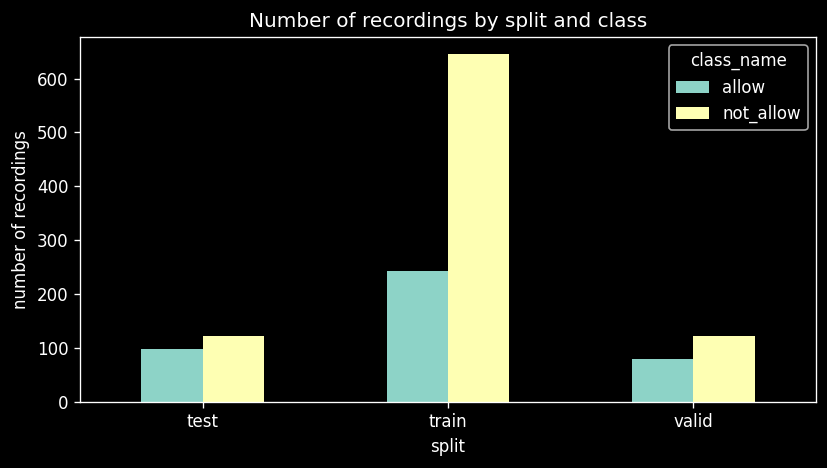

Saved: voice_access_files\results\plots\segment_counts_by_split_class.png


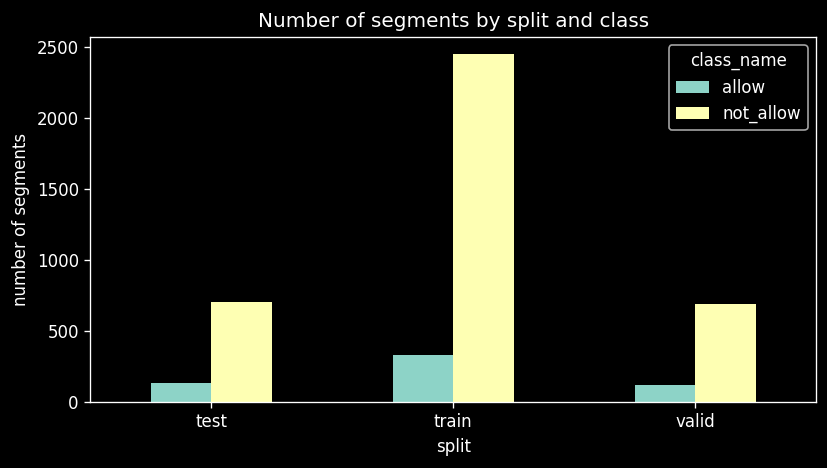

Saved: voice_access_files\results\plots\recording_duration_before_after_preprocessing.png


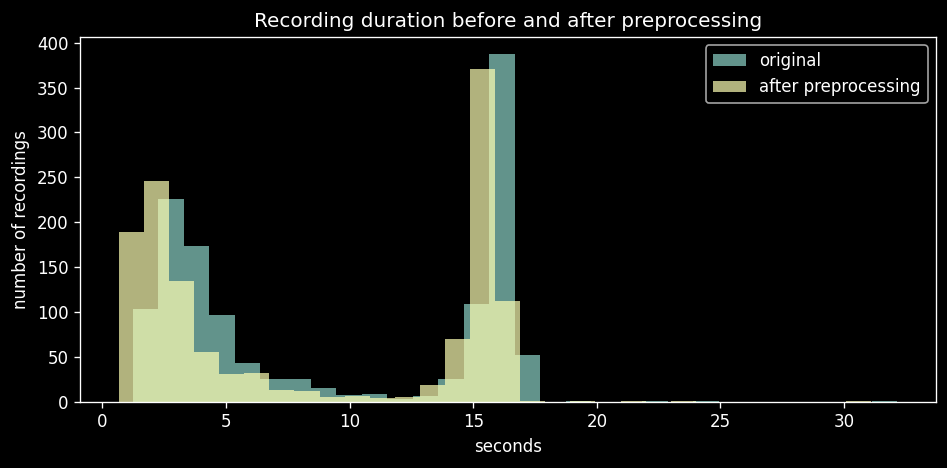

Saved: voice_access_files\results\plots\segments_per_recording_distribution.png


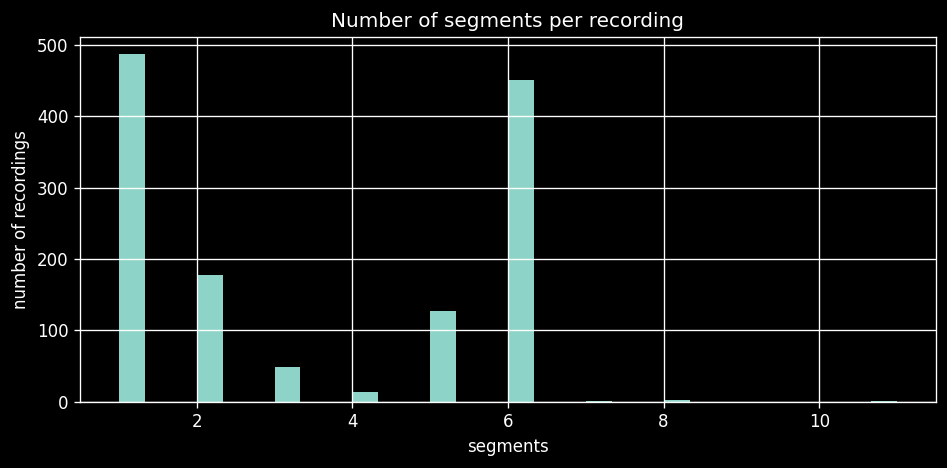

In [8]:
count_table = recording_meta.groupby(["split", "class_name"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
count_table.plot(kind="bar", ax=ax)
ax.set_title("Number of recordings by split and class")
ax.set_xlabel("split")
ax.set_ylabel("number of recordings")
ax.tick_params(axis="x", rotation=0)
save_plot("recording_counts_by_split_class.png")
plt.show()

segment_table = segment_meta.groupby(["split", "class_name"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
segment_table.plot(kind="bar", ax=ax)
ax.set_title("Number of segments by split and class")
ax.set_xlabel("split")
ax.set_ylabel("number of segments")
ax.tick_params(axis="x", rotation=0)
save_plot("segment_counts_by_split_class.png")
plt.show()

recording_duration_df = segment_meta.drop_duplicates("recording_id").copy()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(recording_duration_df["original_seconds"], bins=30, alpha=0.7, label="original")
ax.hist(recording_duration_df["processed_seconds"], bins=30, alpha=0.7, label="after preprocessing")
ax.set_title("Recording duration before and after preprocessing")
ax.set_xlabel("seconds")
ax.set_ylabel("number of recordings")
ax.legend()
save_plot("recording_duration_before_after_preprocessing.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
segment_meta.groupby("recording_id").size().hist(bins=30, ax=ax)
ax.set_title("Number of segments per recording")
ax.set_xlabel("segments")
ax.set_ylabel("number of recordings")
save_plot("segments_per_recording_distribution.png")
plt.show()


## 1.6 Example spectrograms

These plots show randomly selected spectrograms from both classes.


Saved: voice_access_files\results\plots\example_spectrograms_train.png


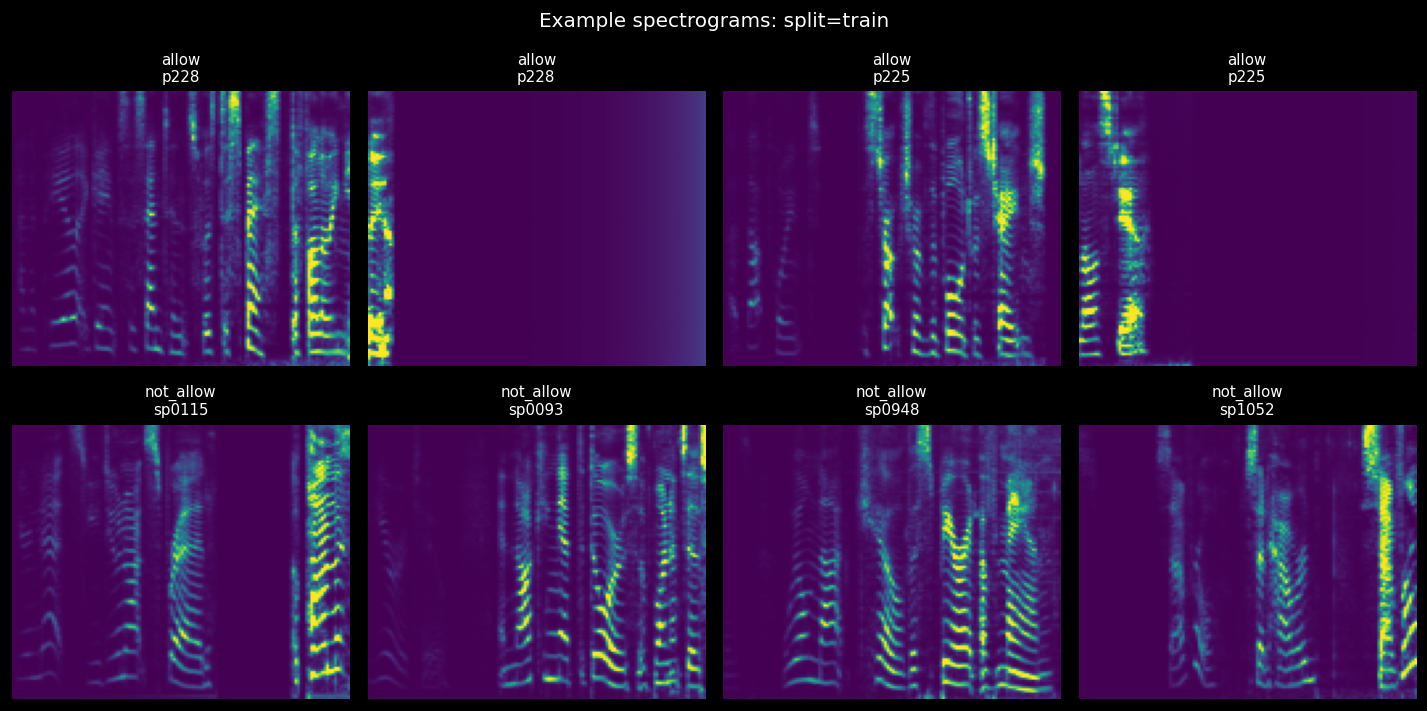

Saved: voice_access_files\results\plots\example_spectrograms_test.png


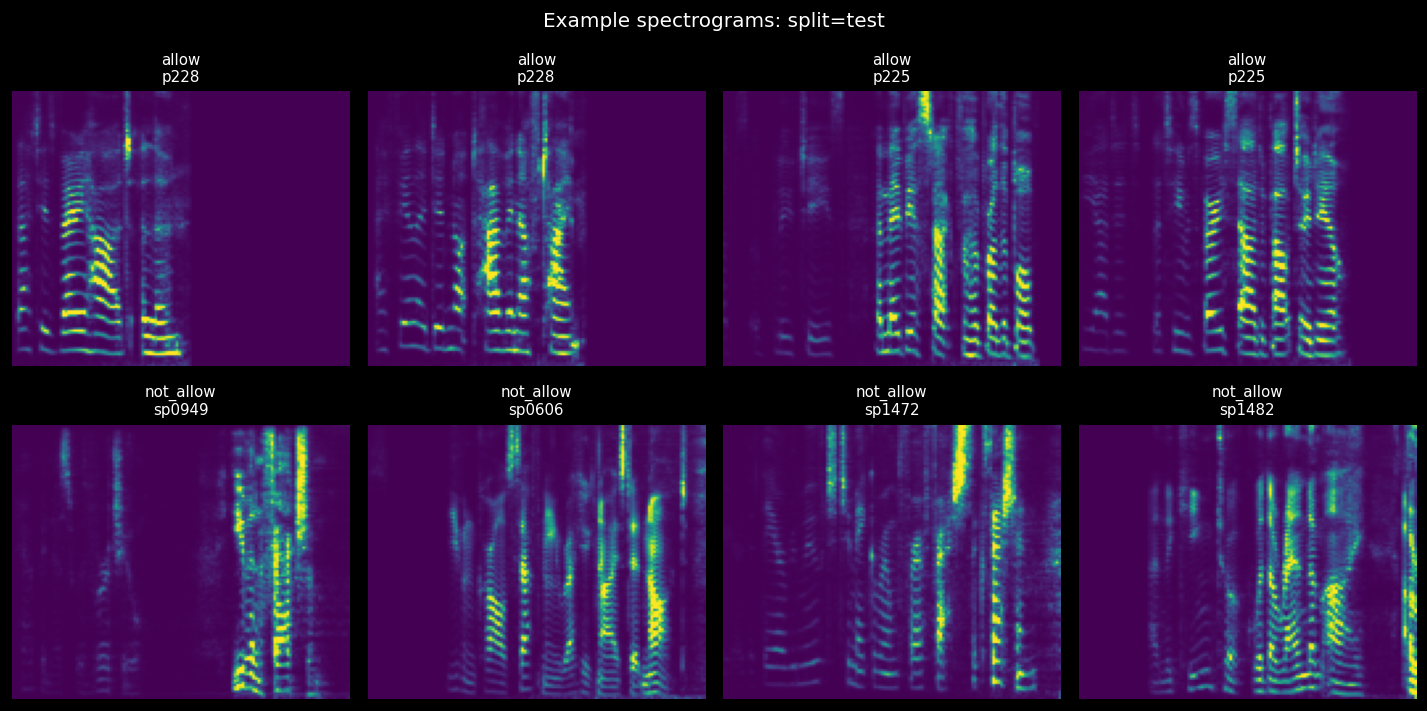

In [9]:
def plot_spectrogram_examples(spec_meta, split="train", n_per_class=4, seed=123):
    rng = np.random.default_rng(seed)
    df = spec_meta[spec_meta["split"] == split].copy()

    rows = []
    for class_name in ["allow", "not_allow"]:
        class_df = df[df["class_name"] == class_name]
        if len(class_df) == 0:
            continue
        sample_size = min(n_per_class, len(class_df))
        chosen_idx = rng.choice(class_df.index.to_numpy(), size=sample_size, replace=False)
        rows.append(class_df.loc[chosen_idx])

    sample_df = pd.concat(rows).reset_index(drop=True)

    n = len(sample_df)
    fig, axes = plt.subplots(2, n_per_class, figsize=(3 * n_per_class, 6))
    axes = np.asarray(axes).reshape(2, n_per_class)

    for ax in axes.ravel():
        ax.axis("off")

    for i, row in sample_df.iterrows():
        r = 0 if row["class_name"] == "allow" else 1
        c = i % n_per_class
        arr = np.load(row["spectrogram_path"])
        axes[r, c].imshow(arr, origin="lower", aspect="auto")
        axes[r, c].set_title(f"{row['class_name']}\n{row['speaker']}", fontsize=9)
        axes[r, c].axis("off")

    fig.suptitle(f"Example spectrograms: split={split}")
    save_plot(f"example_spectrograms_{split}.png")
    plt.show()

plot_spectrogram_examples(spectro_meta, split="train", n_per_class=4, seed=SEED)
plot_spectrogram_examples(spectro_meta, split="test", n_per_class=4, seed=SEED)


## 1.7 Average spectrograms by class

This cell compares the mean training spectrogram for `allow` recordings with the mean training spectrogram for `not_allow` recordings.


Saved: voice_access_files\results\plots\mean_spectrograms_allow_not_allow_difference.png


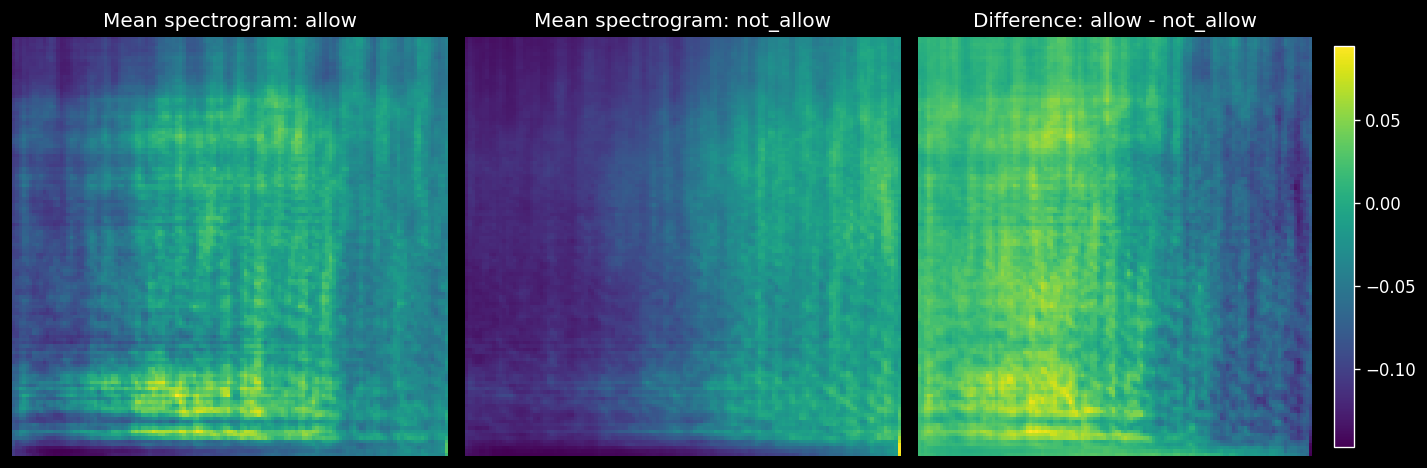

In [10]:
def mean_spectrogram(df, max_items=300, seed=123):
    if len(df) == 0:
        return None
    sample_df = df.sample(min(max_items, len(df)), random_state=seed)
    arrs = [np.load(p).astype(np.float32) for p in sample_df["spectrogram_path"]]
    return np.mean(np.stack(arrs, axis=0), axis=0)

train_specs = spectro_meta[spectro_meta["split"] == "train"].copy()
allow_mean = mean_spectrogram(train_specs[train_specs["class_name"] == "allow"], seed=SEED)
not_allow_mean = mean_spectrogram(train_specs[train_specs["class_name"] == "not_allow"], seed=SEED)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(allow_mean, origin="lower", aspect="auto")
axes[0].set_title("Mean spectrogram: allow")
axes[0].axis("off")

axes[1].imshow(not_allow_mean, origin="lower", aspect="auto")
axes[1].set_title("Mean spectrogram: not_allow")
axes[1].axis("off")

diff = allow_mean - not_allow_mean
im = axes[2].imshow(diff, origin="lower", aspect="auto")
axes[2].set_title("Difference: allow - not_allow")
axes[2].axis("off")
fig.colorbar(im, ax=axes[2], fraction=0.046)

save_plot("mean_spectrograms_allow_not_allow_difference.png")
plt.show()


# 2. Comparison of CNN model families

Here, four CNN-based families are evaluated:
- a plain CNN;
- a residual CNN;
- a lightweight MobileCNN-style architecture;
- a transfer-learning MobileNetV3-based CNN adapted to one-channel spectrogram input.

The selected model is chosen using validation performance, not test performance.


## 2.1 Train and compare model families

This cell trains or loads the four model-family experiments and summarizes their binary and prototype-mode performance.  
The comparison includes validation and test metrics, but the winner is selected using validation metrics only.


In [11]:
experiment_configs = [
    vap.clone_experiment(base_config, experiment_name='plaincnn_default', model_updates={'model_name': 'plaincnn', 'base_channels': 32}),
    vap.clone_experiment(base_config, experiment_name='rescnn_default', model_updates={'model_name': 'rescnn', 'base_channels': 32}),
    vap.clone_experiment(base_config, experiment_name='mobilecnn_default', model_updates={'model_name': 'mobilecnn', 'base_channels': 24}),
    vap.clone_experiment(base_config, experiment_name='transfercnn_default', model_updates={'model_name': 'transfercnn', 'pretrained': True}),
]

comparison_df = vap.compare_experiments(
    experiment_configs,
    rebuild_data_for_first=False,
    clean_intermediate_for_first=False,
)
comparison_df


Training epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Training epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Training epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Training epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Early stopping at epoch 36. Best epoch: 21


,experiment_name,model_name,checkpoint_path,data_signature,selection_split,binary_valid_recording_balanced_error,binary_valid_recording_far,binary_valid_recording_frr,binary_valid_recording_acc,prototype_valid_balanced_error,prototype_valid_far,prototype_valid_frr,binary_test_recording_balanced_error,binary_test_recording_far,binary_test_recording_frr,binary_test_recording_acc,prototype_test_balanced_error,prototype_test_far,prototype_test_frr,prototype_similarity_threshold,n_prototypes
0,rescnn_default,rescnn,voice_access_files\models\rescnn_default.pt,d9e067faca7e3c1c,valid,0.012295,0.024590,0.000000,0.985075,0.014526,0.016393,0.012658,0.014302,0.008197,0.020408,0.986364,0.020408,0.000000,0.040816,0.83,5
1,transfercnn_default,transfercnn,voice_access_files\models\transfercnn_default.pt,d9e067faca7e3c1c,valid,0.016757,0.008197,0.025316,0.985075,0.023086,0.008197,0.037975,0.028605,0.016393,0.040816,0.972727,0.033707,0.016393,0.051020,0.31,5
2,plaincnn_default,plaincnn,voice_access_files\models\plaincnn_default.pt,d9e067faca7e3c1c,valid,0.035381,0.032787,0.037975,0.965174,0.029052,0.032787,0.025316,0.017397,0.024590,0.010204,0.981818,0.015306,0.000000,0.030612,0.84,5
3,mobilecnn_default,mobilecnn,voice_access_files\models\mobilecnn_default.pt,d9e067faca7e3c1c,valid,0.154181,0.131148,0.177215,0.850746,0.156412,0.122951,0.189873,0.153396,0.163934,0.142857,0.845455,0.158498,0.163934,0.153061,0.90,5


## 2.2 Select the best model family on validation data

This cell records the winning model family and checkpoint.  
The test metrics are printed only as a reference; they are not used for model selection.


In [12]:
config_by_name = {cfg.experiment_name: cfg for cfg in experiment_configs}
family_winner_row = comparison_df.iloc[0].to_dict()
family_winner_config = config_by_name[family_winner_row['experiment_name']]
family_winner_checkpoint = family_winner_row['checkpoint_path']

print('Winner selected on split:', family_winner_row['selection_split'])
print('Best family experiment:', family_winner_row['experiment_name'])
print('Best family checkpoint:', family_winner_checkpoint)
print('Best family prototype VALID BE:', family_winner_row['prototype_valid_balanced_error'])
print('Reference prototype TEST BE (not used for selection):', family_winner_row['prototype_test_balanced_error'])


Winner selected on split: valid
Best family experiment: rescnn_default
Best family checkpoint: voice_access_files\models\rescnn_default.pt
Best family prototype VALID BE: 0.014525835235526044
Reference prototype TEST BE (not used for selection): 0.02040816326530612


## 2.3 Visual comparison of model families

The first plot compares balanced error across the model families.  
The second plot focuses on the prototype mode and shows FAR and FRR separately, which is important because false acceptance and false rejection have different practical consequences in an access-control system.


,experiment_name,model_name,checkpoint_path,data_signature,selection_split,binary_valid_recording_balanced_error,binary_valid_recording_far,binary_valid_recording_frr,binary_valid_recording_acc,prototype_valid_balanced_error,prototype_valid_far,prototype_valid_frr,binary_test_recording_balanced_error,binary_test_recording_far,binary_test_recording_frr,binary_test_recording_acc,prototype_test_balanced_error,prototype_test_far,prototype_test_frr,prototype_similarity_threshold,n_prototypes
0,rescnn_default,rescnn,voice_access_files\models\rescnn_default.pt,d9e067faca7e3c1c,valid,0.012295,0.024590,0.000000,0.985075,0.014526,0.016393,0.012658,0.014302,0.008197,0.020408,0.986364,0.020408,0.000000,0.040816,0.83,5
1,transfercnn_default,transfercnn,voice_access_files\models\transfercnn_default.pt,d9e067faca7e3c1c,valid,0.016757,0.008197,0.025316,0.985075,0.023086,0.008197,0.037975,0.028605,0.016393,0.040816,0.972727,0.033707,0.016393,0.051020,0.31,5
2,plaincnn_default,plaincnn,voice_access_files\models\plaincnn_default.pt,d9e067faca7e3c1c,valid,0.035381,0.032787,0.037975,0.965174,0.029052,0.032787,0.025316,0.017397,0.024590,0.010204,0.981818,0.015306,0.000000,0.030612,0.84,5
3,mobilecnn_default,mobilecnn,voice_access_files\models\mobilecnn_default.pt,d9e067faca7e3c1c,valid,0.154181,0.131148,0.177215,0.850746,0.156412,0.122951,0.189873,0.153396,0.163934,0.142857,0.845455,0.158498,0.163934,0.153061,0.90,5


Saved: voice_access_files\results\plots\model_comparison_balanced_error.png


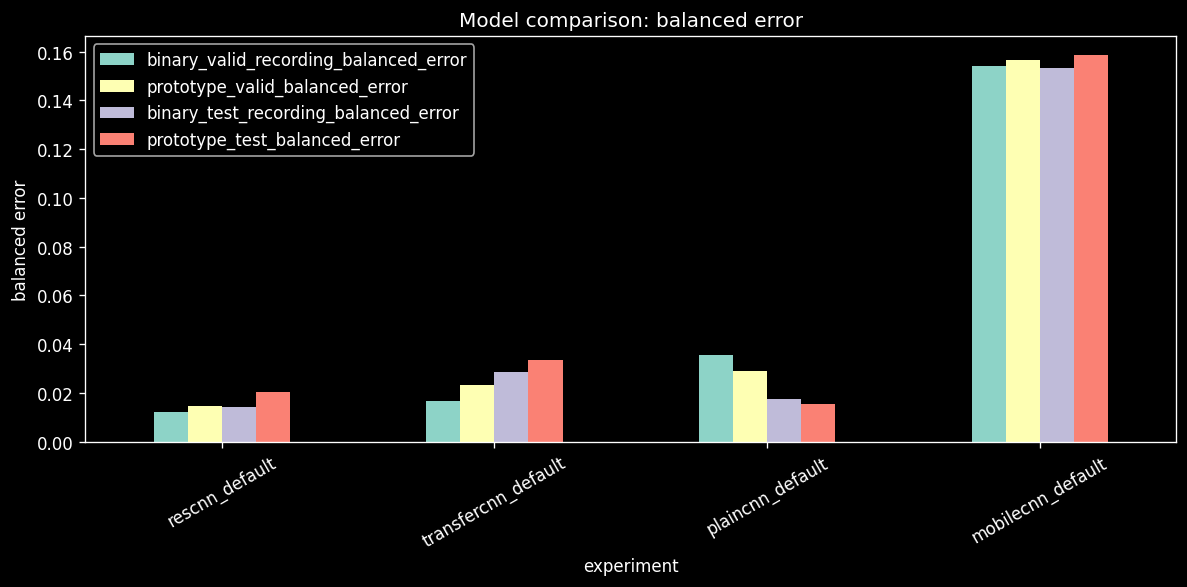

Saved: voice_access_files\results\plots\prototype_far_frr_model_comparison.png


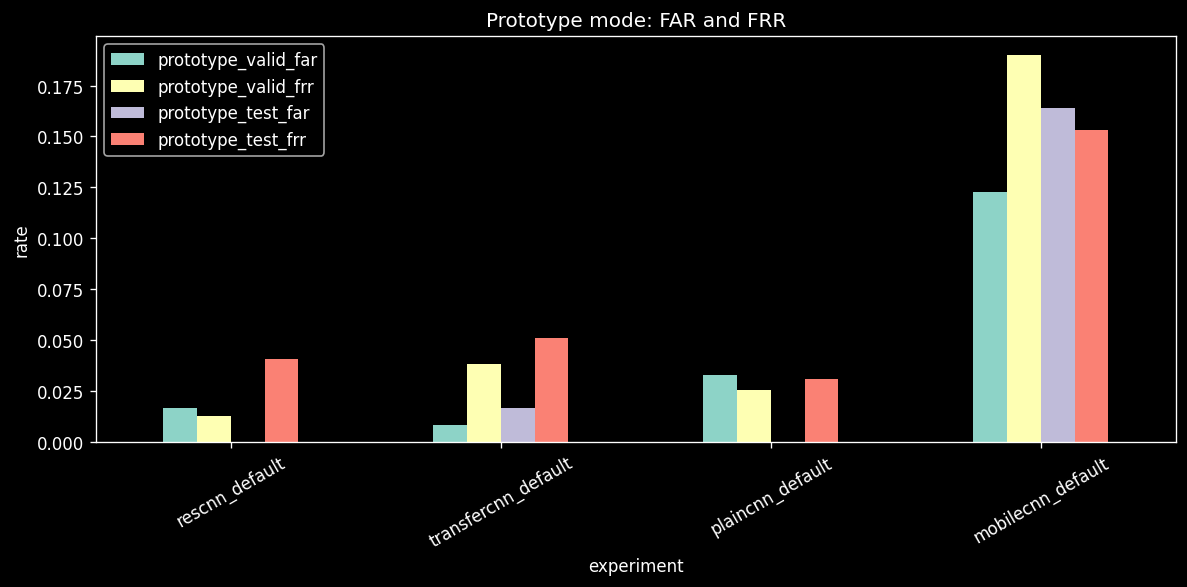

In [13]:
display(comparison_df)

plot_cols = [
    "binary_valid_recording_balanced_error",
    "prototype_valid_balanced_error",
    "binary_test_recording_balanced_error",
    "prototype_test_balanced_error",
]

plot_comparison = comparison_df[["experiment_name"] + plot_cols].copy()
plot_comparison = plot_comparison.set_index("experiment_name")

fig, ax = plt.subplots(figsize=(10, 5))
plot_comparison.plot(kind="bar", ax=ax)
ax.set_title("Model comparison: balanced error")
ax.set_xlabel("experiment")
ax.set_ylabel("balanced error")
ax.tick_params(axis="x", rotation=30)
save_plot("model_comparison_balanced_error.png")
plt.show()

far_frr_cols = [
    "prototype_valid_far",
    "prototype_valid_frr",
    "prototype_test_far",
    "prototype_test_frr",
]

fig, ax = plt.subplots(figsize=(10, 5))
comparison_df.set_index("experiment_name")[far_frr_cols].plot(kind="bar", ax=ax)
ax.set_title("Prototype mode: FAR and FRR")
ax.set_xlabel("experiment")
ax.set_ylabel("rate")
ax.tick_params(axis="x", rotation=30)
save_plot("prototype_far_frr_model_comparison.png")
plt.show()


# 3. Hyperparameter tuning

After selecting the best model family, Optuna is used for a small validation-based hyperparameter search.  
The search tunes training parameters, dropout, and the weights used when choosing the binary decision threshold.


## 3.1 Run Optuna hyperparameter search for the selected ResCNN family

This tuning stage uses the ResCNN family selected in the model-family comparison.
Each Optuna trial is trained from scratch, because the tuned parameters affect the whole training process.

Only validation results are used for the Optuna objective.
The test set is not used during hyperparameter tuning.


In [14]:
finetune_base = vap.clone_experiment(
    family_winner_config,
    experiment_name='finetune_from_family_winner',
    train_updates={
        'epochs': 25,
        'batch_size': 32,
    },
)

trials_df, finetune_best = vap.optimize_experiment_with_optuna(
    finetune_base,
    n_trials=5,
    rebuild_data_for_first_trial=False,
    init_checkpoint_path=None,
    allow_data_tuning=False,
)

trials_df.head(), finetune_best

[I 2026-05-23 17:04:14,343] A new study created in memory with name: no-name-7bcb79ca-e635-49ae-965a-75f295cdbdf3


Training epochs:   0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-05-23 19:41:06,150] Trial 0 finished with value: 0.08929238431209795 and parameters: {'dropout': 0.37858767423914463, 'base_channels': 48, 'lr': 0.00035520101324997705, 'weight_decay': 0.0004436629399695339, 'threshold_false_accept_weight': 3.739318954339453, 'threshold_false_reject_weight': 1.2213978522265414, 'threshold_penalty_gap': 0.2940881386456129}. Best is trial 0 with value: 0.08929238431209795.


Training epochs:   0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-05-23 20:16:28,769] Trial 1 finished with value: 0.07576260634986512 and parameters: {'dropout': 0.23727120646034777, 'base_channels': 16, 'lr': 0.0009123346291227039, 'weight_decay': 3.108420085359682e-06, 'threshold_false_accept_weight': 1.7018070245899701, 'threshold_false_reject_weight': 1.2973270607627576, 'threshold_penalty_gap': 0.39887069032264955}. Best is trial 1 with value: 0.07576260634986512.


...

Training epochs:   0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-05-23 22:18:23,947] Trial 3 finished with value: 0.10321643494500934 and parameters: {'dropout': 0.13684197597803008, 'base_channels': 32, 'lr': 0.00025483625698289393, 'weight_decay': 1.4148467085264879e-05, 'threshold_false_accept_weight': 4.57355665246854, 'threshold_false_reject_weight': 1.9162400273058195, 'threshold_penalty_gap': 0.37637750691325245}. Best is trial 1 with value: 0.07576260634986512.


Training epochs:   0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-05-24 00:55:49,978] Trial 4 finished with value: 0.10402573147956008 and parameters: {'dropout': 0.3495811807168445, 'base_channels': 48, 'lr': 0.0002117629327422142, 'weight_decay': 2.0123104861591988e-05, 'threshold_false_accept_weight': 4.94223914244282, 'threshold_false_reject_weight': 1.279227678889714, 'threshold_penalty_gap': 0.45967089432222574}. Best is trial 1 with value: 0.07576260634986512.


(   trial_number                        experiment_name  \
 0             1  finetune_from_family_winner_trial_001   
 1             0  finetune_from_family_winner_trial_000   
 2             3  finetune_from_family_winner_trial_003   
 3             4  finetune_from_family_winner_trial_004   
 4             2  finetune_from_family_winner_trial_002   
 
                                      checkpoint_path  objective  \
 0  voice_access_files\models\finetune_from_family...   0.075763   
 1  voice_access_files\models\finetune_from_family...   0.089292   
 2  voice_access_files\models\finetune_from_family...   0.103216   
 3  voice_access_files\models\finetune_from_family...   0.104026   
 4  voice_access_files\models\finetune_from_family...   0.161361   
 
    prototype_valid_far  prototype_valid_frr  prototype_valid_balanced_error  \
 0             0.040984             0.037975                        0.039479   
 1             0.024590             0.063291                        0.0439

## 3.2 Convert Optuna parameters into project configuration updates

Optuna returns a flat dictionary of parameters.  
This helper function splits them into the correct configuration groups: model updates, training updates, and data-preparation updates.


In [15]:
def split_best_params(best_summary):
    params = dict(best_summary['params'])
    model_updates = {}
    train_updates = {}
    data_updates = {}
    for key, value in params.items():
        if key in {'dropout', 'base_channels'}:
            model_updates[key] = value
        elif key in {'lr', 'weight_decay',  'optimizer_name', 'threshold_false_accept_weight', 'threshold_false_reject_weight', 'threshold_penalty_gap',}:
            train_updates[key] = value
        elif key in {'segment_seconds', 'trim_top_db'}:
            data_updates[key] = value
    return model_updates, train_updates, data_updates

best_model_updates, best_train_updates, best_data_updates = split_best_params(finetune_best)

best_finetune_config = vap.clone_experiment(
    finetune_base,
    experiment_name=finetune_best['experiment_name'],
    data_updates=best_data_updates or None,
    model_updates=best_model_updates or None,
    train_updates=best_train_updates or None,
)

print(best_finetune_config)
print('Best tuned checkpoint:', finetune_best['checkpoint_path'])


ExperimentConfig(experiment_name='finetune_from_family_winner_trial_001', data=DataPrepConfig(source_dir=WindowsPath('VOiCES_devkit/source-16k'), work_dir=WindowsPath('voice_access_files'), allow_speakers=None, allow_speaker_prefix='p', n_allow_speakers=5, seed=123, train_ratio=0.6, valid_ratio=0.2, target_allow_speakers_in_valid=2, sample_rate=16000, segment_seconds=3.0, keep_remainder=True, trim_silence=True, trim_top_db=25.0, remove_dc_offset=True, normalize_peak=False, peak_target=0.98, normalize_rms=True, target_rms_db=-20.0, preemphasis=0.97, image_size=128, n_mels=128, spectrogram_mode='pcen', spec_norm_min_percentile=1.0, spec_norm_max_percentile=99.0, mel_fmin=20.0, mel_fmax=7600.0, deduplicate_audio=True, duplicate_hash_max_seconds=None), model=ModelConfig(model_name='rescnn', base_channels=16, dropout=0.23727120646034777, use_batchnorm=True, embedding_dim=64, pretrained=False), train=TrainConfig(batch_size=32, epochs=25, lr=0.0009123346291227039, optimizer_name='adamw', weig

## 3.3 Inspect the Optuna search

These plots show how the objective changed across trials and how individual tuned parameters relate to the objective. In this project, the Optuna objective is a validation-based score combining the false acceptance ratio, false rejection ratio, and the imbalance between them. Lower objective values are better. The objective gives more weight to false acceptances, because accepting a not-allowed speaker is more harmful in an access-control system than rejecting an allowed speaker.


,trial_number,experiment_name,checkpoint_path,objective,prototype_valid_far,prototype_valid_frr,prototype_valid_balanced_error,prototype_valid_gap_far_frr,dropout,base_channels,lr,weight_decay,threshold_false_accept_weight,threshold_false_reject_weight,threshold_penalty_gap
0,1,finetune_from_family_winner_trial_001,voice_access_files\models\finetune_from_family...,0.075763,0.040984,0.037975,0.039479,0.003009,0.237271,16,0.000912,0.000003,1.701807,1.297327,0.398871
1,0,finetune_from_family_winner_trial_000,voice_access_files\models\finetune_from_family...,0.089292,0.024590,0.063291,0.043941,0.038701,0.378588,48,0.000355,0.000444,3.739319,1.221398,0.294088
2,3,finetune_from_family_winner_trial_003,voice_access_files\models\finetune_from_family...,0.103216,0.024590,0.075949,0.050270,0.051359,0.136842,32,0.000255,0.000014,4.573557,1.916240,0.376378
3,4,finetune_from_family_winner_trial_004,voice_access_files\models\finetune_from_family...,0.104026,0.008197,0.088608,0.048402,0.080411,0.349581,48,0.000212,0.000020,4.942239,1.279228,0.459671
4,2,finetune_from_family_winner_trial_002,voice_access_files\models\finetune_from_family...,0.161361,0.090164,0.075949,0.083057,0.014215,0.353760,16,0.000263,0.000009,1.913053,0.940571,0.473232


Saved: voice_access_files\results\plots\optuna_objective_by_trial.png


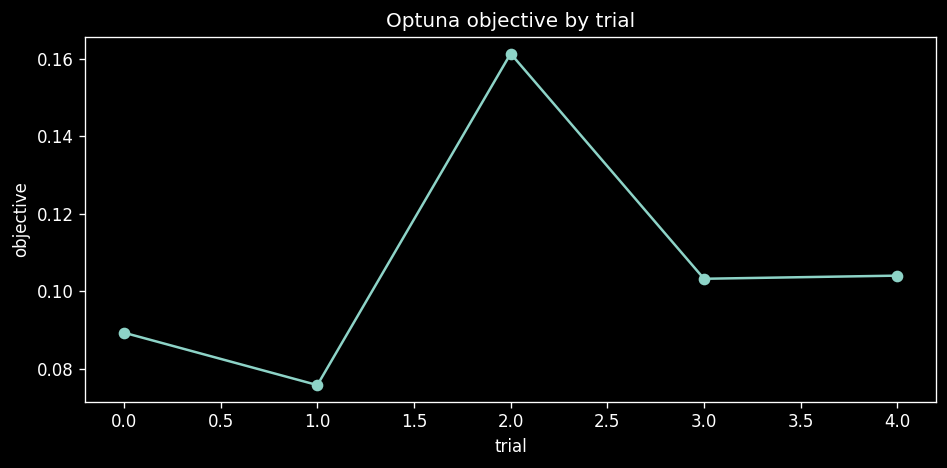

Saved: voice_access_files\results\plots\optuna_objective_vs_lr.png


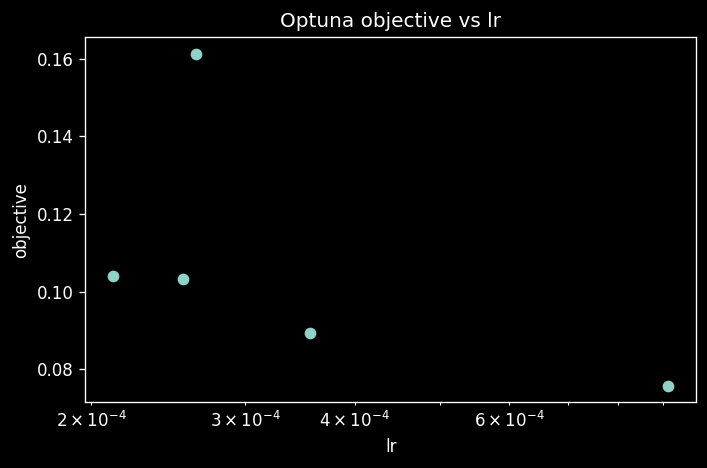

Saved: voice_access_files\results\plots\optuna_objective_vs_weight_decay.png


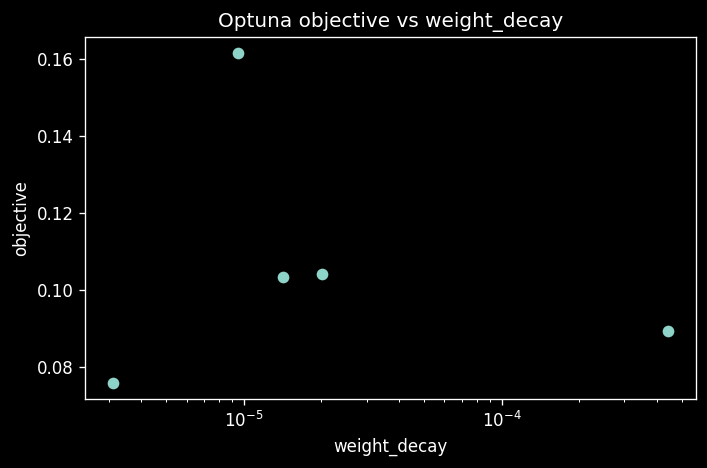

Saved: voice_access_files\results\plots\optuna_objective_vs_dropout.png


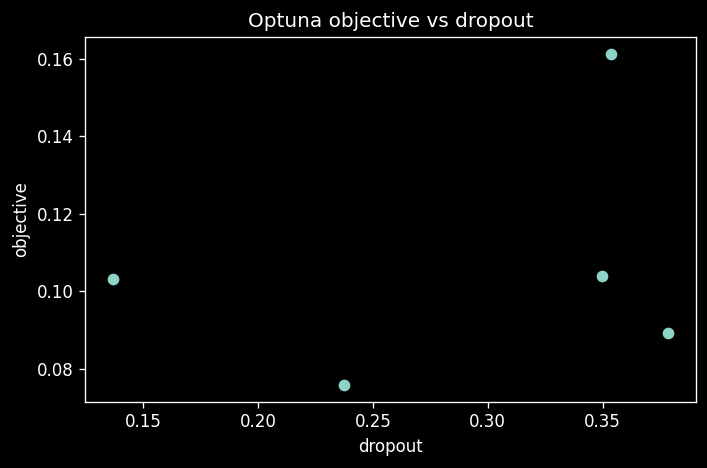

Saved: voice_access_files\results\plots\optuna_objective_vs_base_channels.png


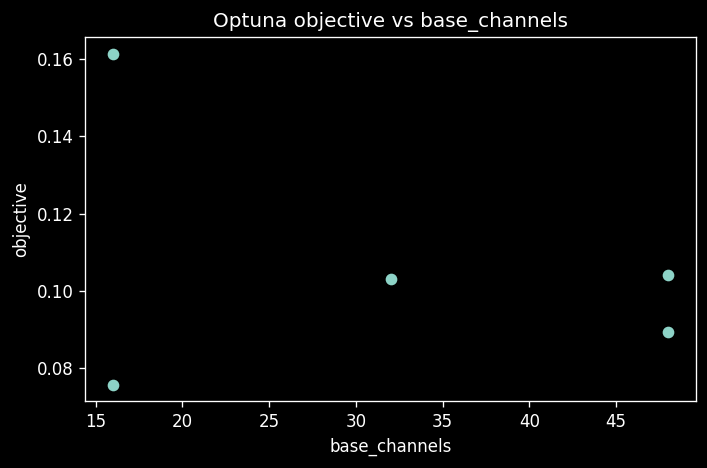

Saved: voice_access_files\results\plots\optuna_objective_vs_threshold_false_accept_weight.png


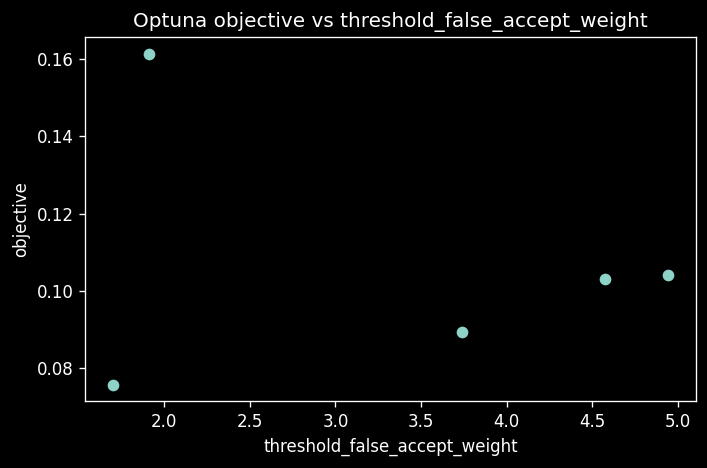

Saved: voice_access_files\results\plots\optuna_objective_vs_threshold_false_reject_weight.png


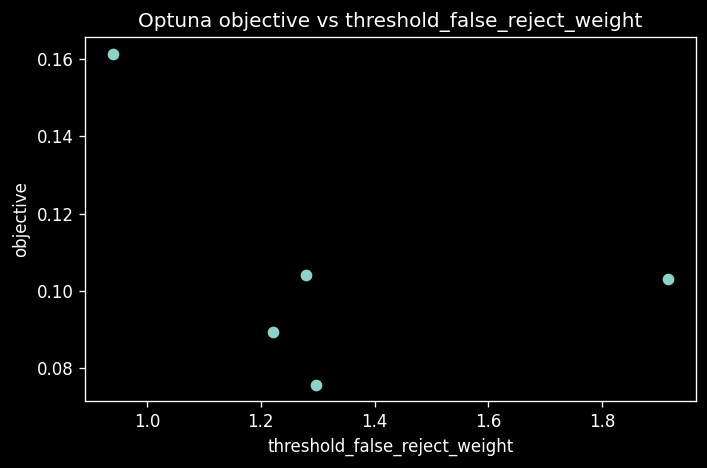

Saved: voice_access_files\results\plots\optuna_objective_vs_threshold_penalty_gap.png


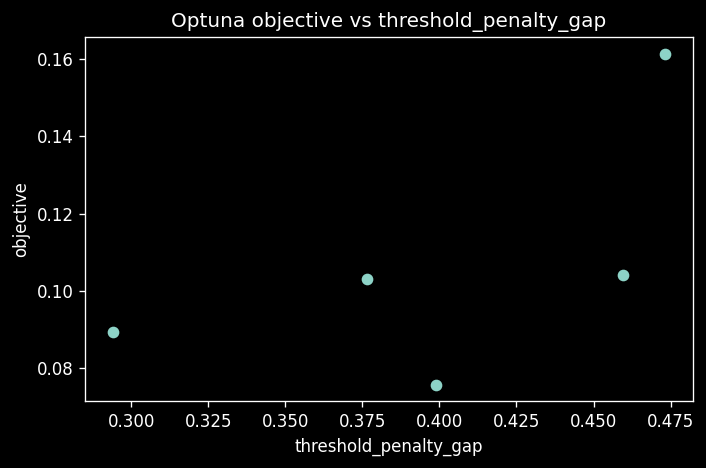

In [16]:
display(trials_df.head(10))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(trials_df.sort_values("trial_number")["trial_number"],
        trials_df.sort_values("trial_number")["objective"],
        marker="o")
ax.set_title("Optuna objective by trial")
ax.set_xlabel("trial")
ax.set_ylabel("objective")
save_plot("optuna_objective_by_trial.png")
plt.show()

candidate_param_cols = [
    "lr",
    "weight_decay",
    "dropout",
    "base_channels",
    "threshold_false_accept_weight",
    "threshold_false_reject_weight",
    "threshold_penalty_gap",
]

for col in candidate_param_cols:
    if col not in trials_df.columns:
        continue

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(trials_df[col], trials_df["objective"])
    ax.set_title(f"Optuna objective vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("objective")
    if col in {"lr", "weight_decay"}:
        ax.set_xscale("log")
    save_plot(f"optuna_objective_vs_{col}.png")
    plt.show()


# 4. Final operational model

The final operational model uses the best tuned ResCNN configuration found in the Optuna search.
It is initialized from the best tuned checkpoint and then run once more as the final training stage.

After training, the notebook evaluates both:

- the binary classifier head, used as a reference result;
- the prototype-based operational mode, used by the final application.

Prototype mode is the final product mode because it supports adding new allowed speakers by updating the prototype index, without retraining the whole CNN from scratch.

## 4.1 Train and evaluate the final model

This cell creates the final experiment configuration, runs the final training stage, evaluates binary-mode performance, and builds the prototype index for the operational mode.


In [17]:
final_config = vap.clone_experiment(
    best_finetune_config,
    experiment_name='final_operational_model',
    train_updates={
        'epochs': 40,
        'batch_size': 32,
        'lr': float(best_finetune_config.train.lr),
    },
)

history, binary_results, prototype_summary = vap.run_full_experiment(
    final_config,
    rebuild_data=False,
    clean_intermediate=False,
    init_checkpoint_path=finetune_best['checkpoint_path'],
)

history.tail(), binary_results, prototype_summary


Training epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Early stopping at epoch 15. Best epoch: 0


(    epoch  train_loss  valid_loss  pos_weight        lr  best_threshold  \
 11     11    0.492672    0.666965     7.51227  0.000228            0.57   
 12     12    0.400163    0.789340     7.51227  0.000228            0.57   
 13     13    0.409416    0.878333     7.51227  0.000228            0.57   
 14     14    0.469273    0.647067     7.51227  0.000114            0.57   
 15     15    0.329779    0.938903     7.51227  0.000114            0.57   
 
     best_valid_balanced_accuracy  threshold_false_accept_weight  \
 11                      0.964619                       1.701807   
 12                      0.964619                       1.701807   
 13                      0.964619                       1.701807   
 14                      0.964619                       1.701807   
 15                      0.964619                       1.701807   
 
     threshold_false_reject_weight  threshold_penalty_gap  \
 11                       1.297327               0.398871   
 12       

## 4.2 Save recording-level scores for diagnostics

This cell computes recording-level scores for every split and for both modes:

- binary mode uses the classifier probability and a validation-selected probability threshold;
- prototype mode uses cosine similarity to the closest allowed-speaker prototype and a validation-selected similarity threshold.

The resulting table is saved and reused by the following diagnostic plots.


In [18]:
final_checkpoint = vap.get_experiment_checkpoint_path(final_config)
model, ckpt, final_paths = vap.load_checkpoint_bundle(final_config, checkpoint_path=final_checkpoint)

_, train_eval_loader, valid_loader, test_loader, _ = vap.make_loaders(
    paths=final_paths,
    image_size=int(ckpt.get("image_size", final_config.data.image_size)),
    batch_size=final_config.train.batch_size,
    augment=False,
    num_workers=final_config.train.num_workers,
    device=final_config.train.device,
    normalizer_mean=ckpt.get("train_mean"),
    normalizer_std=ckpt.get("train_std"),
)

loaders = {
    "train": train_eval_loader,
    "valid": valid_loader,
    "test": test_loader,
}

binary_threshold = float(ckpt.get("threshold", 0.5))
binary_aggregation = str(ckpt.get("aggregation_method", final_config.train.aggregation_method))

speaker_index = vap.load_speaker_index(final_paths.speaker_index_path)
if len(speaker_index["prototypes"]) == 0:
    vap.build_speaker_index_for_experiment(final_config)
    speaker_index = vap.load_speaker_index(final_paths.speaker_index_path)

prototype_threshold = float(speaker_index["similarity_threshold"])

score_frames = []

for split, loader in loaders.items():
    binary_eval = vap.evaluate_binary_model(
        model=model,
        loader=loader,
        device=final_config.train.device,
        threshold=binary_threshold,
        aggregation_method=binary_aggregation,
    )

    binary_df = binary_eval["recording_df"].copy()
    binary_df = binary_df.rename(columns={"p_allow": "score"})
    binary_df["mode"] = "binary"
    binary_df["split"] = split
    binary_df["threshold"] = binary_threshold
    binary_df["predicted_label"] = (binary_df["score"] >= binary_threshold).astype(int)
    score_frames.append(binary_df)

    proto_eval = vap.evaluate_prototype_with_loader(
        model=model,
        loader=loader,
        device=final_config.train.device,
        prototypes=speaker_index["prototypes"],
        similarity_threshold=prototype_threshold,
        aggregation_method=final_config.prototype.segment_aggregation_method,
    )

    proto_df = proto_eval["recording_df"].copy()
    proto_df["audio_path"] = None
    proto_df["n_segments"] = None
    proto_df["mode"] = "prototype"
    proto_df["split"] = split
    proto_df["threshold"] = prototype_threshold
    score_frames.append(proto_df)

score_df = pd.concat(score_frames, ignore_index=True)
score_df["class_name"] = np.where(score_df["y_true"] == 1, "allow", "not_allow")
score_df["is_error"] = score_df["y_true"] != score_df["predicted_label"]
score_df["signed_margin"] = score_df["score"] - score_df["threshold"]
score_df["abs_margin"] = score_df["signed_margin"].abs()

score_out_path = final_paths.results_dir / f"{final_config.experiment_name}_recording_scores.csv"
score_df.to_csv(score_out_path, index=False)
print(f"Saved: {score_out_path}")

display(score_df.head())


Saved: voice_access_files\results\final_operational_model_recording_scores.csv


,recording_id,speaker,audio_path,y_true,score,n_segments,mode,split,threshold,predicted_label,best_speaker,class_name,is_error,signed_margin,abs_margin
0,lect__recorded_sample_001,lect,VOiCES_devkit\source-16k\lect\recorded_sample_...,0,0.011772,8,binary,train,0.57,0,NaN,not_allow,False,-0.558228,0.558228
1,p226__p226_001_mic1,p226,VOiCES_devkit\source-16k\p226\p226_001_mic1.wav,0,0.053124,1,binary,train,0.57,0,NaN,not_allow,False,-0.516876,0.516876
2,p226__p226_002_mic1,p226,VOiCES_devkit\source-16k\p226\p226_002_mic1.wav,0,0.082920,1,binary,train,0.57,0,NaN,not_allow,False,-0.487080,0.487080
3,p226__p226_003_mic1,p226,VOiCES_devkit\source-16k\p226\p226_003_mic1.wav,0,0.243476,3,binary,train,0.57,0,NaN,not_allow,False,-0.326524,0.326524
4,p226__p226_004_mic1,p226,VOiCES_devkit\source-16k\p226\p226_004_mic1.wav,0,0.255832,2,binary,train,0.57,0,NaN,not_allow,False,-0.314168,0.314168


## 4.3 Score distributions

These histograms compare score distributions for `allow` and `not_allow` recordings on validation and test sets.  
A good model should separate the two classes, with the threshold placed between them. Overlap indicates difficult or ambiguous recordings.


Saved: voice_access_files\results\plots\score_distribution_binary_valid.png


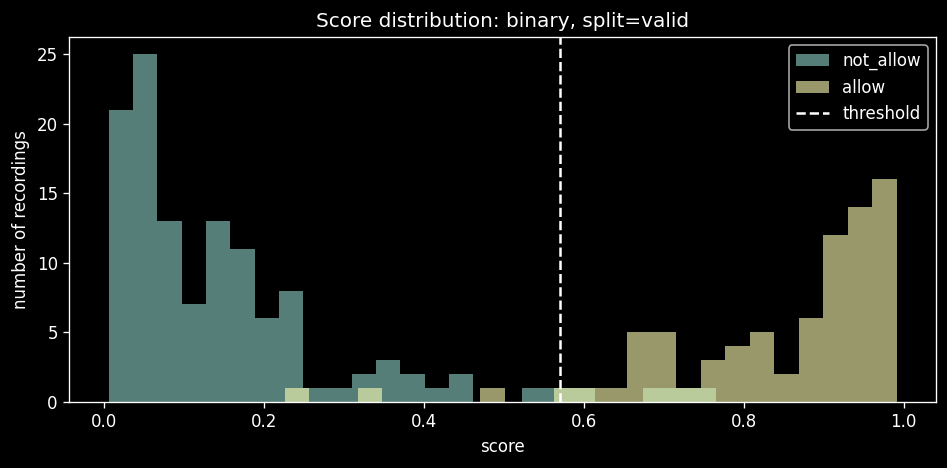

Saved: voice_access_files\results\plots\score_distribution_binary_test.png


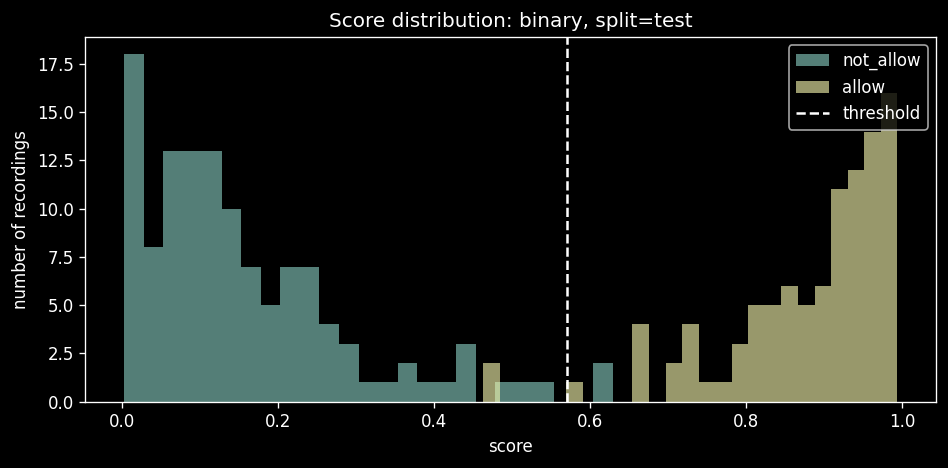

Saved: voice_access_files\results\plots\score_distribution_prototype_valid.png


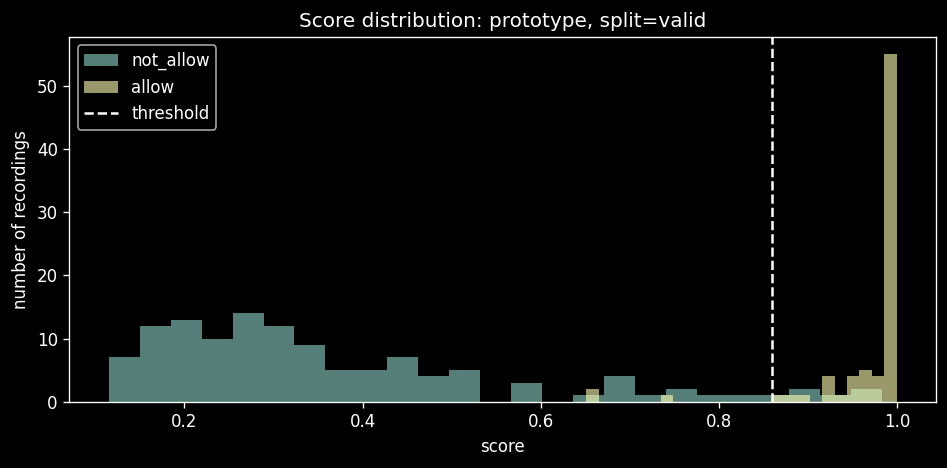

Saved: voice_access_files\results\plots\score_distribution_prototype_test.png


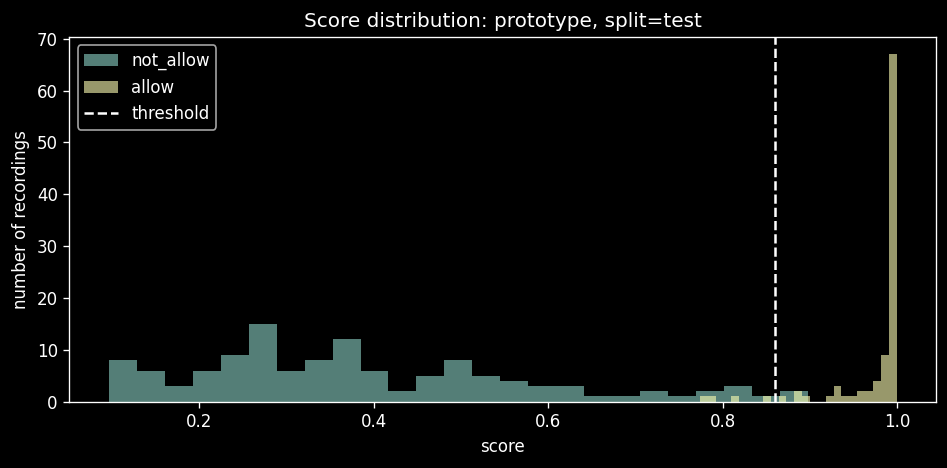

In [19]:
for mode in ["binary", "prototype"]:
    for split in ["valid", "test"]:
        g = score_df[(score_df["mode"] == mode) & (score_df["split"] == split)].copy()
        if len(g) == 0:
            continue

        fig, ax = plt.subplots(figsize=(8, 4))

        for y_true, label in [(0, "not_allow"), (1, "allow")]:
            vals = g.loc[g["y_true"] == y_true, "score"]
            if len(vals) > 0:
                ax.hist(vals, bins=25, alpha=0.6, label=label)

        ax.axvline(g["threshold"].iloc[0], linestyle="--", label="threshold")
        ax.set_title(f"Score distribution: {mode}, split={split}")
        ax.set_xlabel("score")
        ax.set_ylabel("number of recordings")
        ax.legend()
        save_plot(f"score_distribution_{mode}_{split}.png")
        plt.show()


## 4.4 Confusion matrices and difficult samples

This cell prints confusion matrices for train, validation, and test splits.  
It also lists the most confident mistakes and the correct predictions closest to the threshold.


In [20]:
for mode in ["binary", "prototype"]:
    for split in ["train", "valid", "test"]:
        g = score_df[(score_df["mode"] == mode) & (score_df["split"] == split)].copy()
        if len(g) == 0:
            continue

        print(f"\nConfusion matrix: mode={mode}, split={split}")
        cm = pd.crosstab(
            g["y_true"],
            g["predicted_label"],
            rownames=["true"],
            colnames=["predicted"],
            dropna=False,
        )
        display(cm)

print("Most confident wrong predictions:")
hard_errors = (
    score_df[score_df["is_error"]]
    .sort_values("abs_margin", ascending=False)
    [["mode", "split", "recording_id", "speaker", "class_name", "score", "threshold", "signed_margin", "predicted_label"]]
)
display(hard_errors.head(20))

print("Correct predictions closest to the threshold:")
near_threshold_correct = (
    score_df[~score_df["is_error"]]
    .sort_values("abs_margin", ascending=True)
    [["mode", "split", "recording_id", "speaker", "class_name", "score", "threshold", "signed_margin", "predicted_label"]]
)
display(near_threshold_correct.head(20))

hard_errors.to_csv(final_paths.results_dir / f"{final_config.experiment_name}_hard_errors.csv", index=False)
near_threshold_correct.to_csv(final_paths.results_dir / f"{final_config.experiment_name}_near_threshold_correct.csv", index=False)



Confusion matrix: mode=binary, split=train


predicted,0,1
true,,
0,488,157
1,2,241



Confusion matrix: mode=binary, split=valid


predicted,0,1
true,,
0,118,4
1,3,76



Confusion matrix: mode=binary, split=test


...

predicted,0,1
true,,
0,120,2
1,4,94


Most confident wrong predictions:


,mode,split,recording_id,speaker,class_name,score,threshold,signed_margin,predicted_label
217,binary,train,p229__p229_037_mic1,p229,not_allow,0.984860,0.57,0.414860,1
285,binary,train,p230__p230_065_mic1,p230,not_allow,0.974125,0.57,0.404125,1
216,binary,train,p229__p229_036_mic1,p229,not_allow,0.973361,0.57,0.403361,1
223,binary,train,p229__p229_043_mic1,p229,not_allow,0.969477,0.57,0.399477,1
182,binary,train,p229__p229_002_mic1,p229,not_allow,0.965466,0.57,0.395466,1
214,binary,train,p229__p229_034_mic1,p229,not_allow,0.962166,0.57,0.392166,1
246,binary,train,p230__p230_026_mic1,p230,not_allow,0.961831,0.57,0.391831,1
259,binary,train,p230__p230_039_mic1,p230,not_allow,0.949231,0.57,0.379231,1
209,binary,train,p229__p229_029_mic1,p229,not_allow,0.948728,0.57,0.378728,1
26,binary,train,p226__p226_026_mic1,p226,not_allow,0.947526,0.57,0.377526,1


Correct predictions closest to the threshold:


,mode,split,recording_id,speaker,class_name,score,threshold,signed_margin,predicted_label
1140,prototype,train,p230__p230_032_mic1,p230,not_allow,0.859962,0.86,-0.000038,0
1513,prototype,train,sp8225__Lab41-SRI-VOiCES-src-sp8225-ch274375-s...,sp8225,not_allow,0.858139,0.86,-0.001861,0
2031,prototype,valid,sp2764__Lab41-SRI-VOiCES-src-sp2764-ch036616-s...,sp2764,not_allow,0.857334,0.86,-0.002666,0
1114,prototype,train,p230__p230_002_mic1,p230,not_allow,0.856797,0.86,-0.003203,0
1845,binary,valid,sp4014__Lab41-SRI-VOiCES-src-sp4014-ch186176-s...,sp4014,not_allow,0.566736,0.57,-0.003264,0
953,prototype,train,p226__p226_067_mic1,p226,not_allow,0.856631,0.86,-0.003369,0
261,binary,train,p230__p230_041_mic1,p230,not_allow,0.566555,0.57,-0.003445,0
130,binary,train,p226__p226_135_mic1,p226,not_allow,0.566396,0.57,-0.003604,0
1900,binary,valid,p225__p225_008_mic1,p225,allow,0.574768,0.57,0.004768,1
947,prototype,train,p226__p226_061_mic1,p226,not_allow,0.855105,0.86,-0.004895,0


## 4.5 Final fine-tuning history

This plot shows the training and validation loss during the final fine-tuning stage.  
The vertical dashed line marks the checkpoint selected by the validation loss. If epoch 0 is selected, it means the initialized tuned checkpoint was better than later fine-tuning epochs.


Saved: voice_access_files\results\plots\final_model_training_history.png


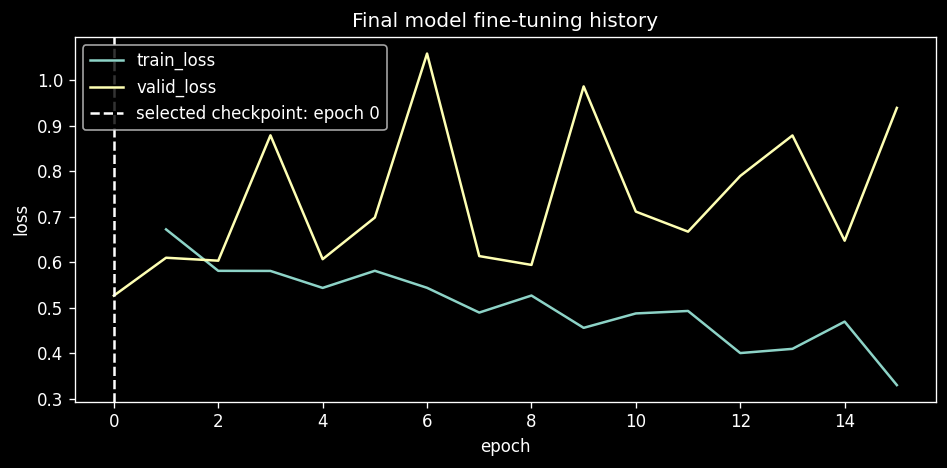

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))

plot_history = history.copy()
ax.plot(plot_history["epoch"], plot_history["train_loss"], label="train_loss")
ax.plot(plot_history["epoch"], plot_history["valid_loss"], label="valid_loss")

best_epoch = int(history.loc[history["valid_loss"].idxmin(), "epoch"])
ax.axvline(best_epoch, linestyle="--", label=f"selected checkpoint: epoch {best_epoch}")

ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.legend()
ax.set_title("Final model fine-tuning history")
save_plot("final_model_training_history.png")
plt.show()


## 4.6 Embedding-space exploration with PCA

This cell projects recording embeddings into two dimensions using PCA.  
The plots show whether `allow` and `not_allow` recordings, or train/validation/test recordings, form visibly different regions in the learned embedding space.


Saved: voice_access_files\results\plots\recording_embeddings_pca_by_class.png


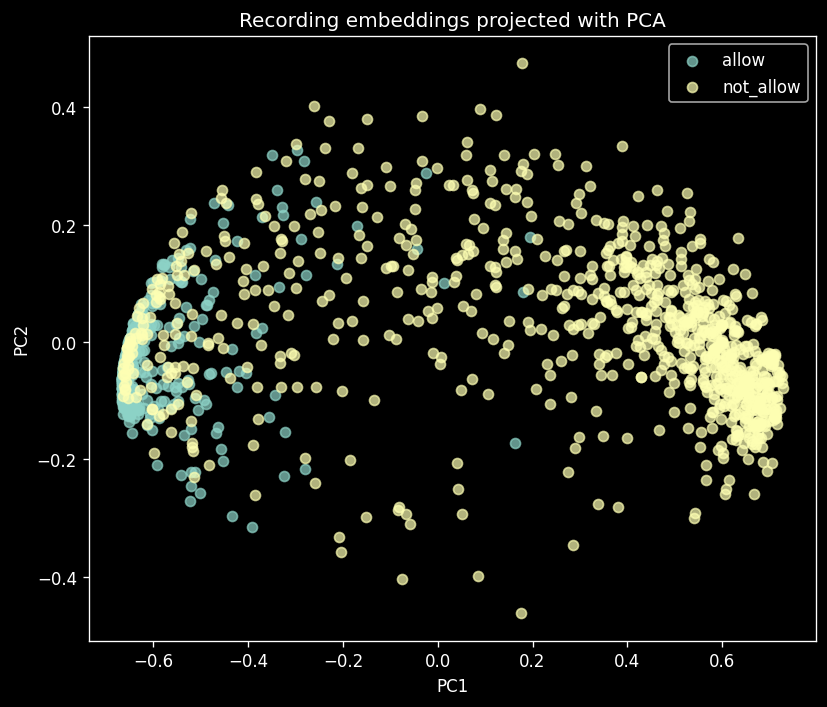

Saved: voice_access_files\results\plots\recording_embeddings_pca_by_split.png


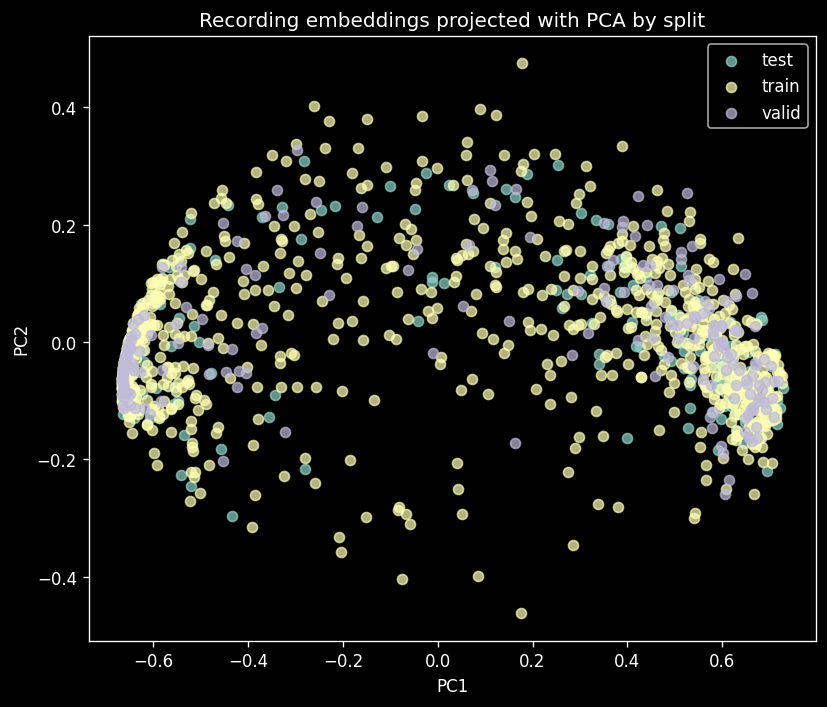

In [22]:
embedding_frames = []

for split, loader in loaders.items():
    seg_emb_df = vap.collect_segment_embeddings(
        model=model,
        loader=loader,
        device=final_config.train.device,
    )
    rec_emb_df = vap.aggregate_recording_embeddings(
        seg_emb_df,
        method=final_config.prototype.segment_aggregation_method,
    )
    rec_emb_df["split"] = split
    embedding_frames.append(rec_emb_df)

embedding_df = pd.concat(embedding_frames, ignore_index=True)

X_emb = np.stack(embedding_df["embedding"].to_list(), axis=0)
coords = PCA(n_components=2, random_state=SEED).fit_transform(X_emb)

embedding_plot_df = embedding_df.drop(columns=["embedding"]).copy()
embedding_plot_df["PC1"] = coords[:, 0]
embedding_plot_df["PC2"] = coords[:, 1]
embedding_plot_df["class_name"] = np.where(embedding_plot_df["y_true"] == 1, "allow", "not_allow")

embedding_plot_df.to_csv(final_paths.results_dir / f"{final_config.experiment_name}_embedding_pca.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 6))

for class_name, g in embedding_plot_df.groupby("class_name"):
    ax.scatter(g["PC1"], g["PC2"], label=class_name, alpha=0.7)

ax.set_title("Recording embeddings projected with PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
save_plot("recording_embeddings_pca_by_class.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))

for split, g in embedding_plot_df.groupby("split"):
    ax.scatter(g["PC1"], g["PC2"], label=split, alpha=0.7)

ax.set_title("Recording embeddings projected with PCA by split")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
save_plot("recording_embeddings_pca_by_split.png")
plt.show()


## 4.7 Similarity between allowed-speaker prototypes

The prototype matrix shows cosine similarities between the stored allowed-speaker prototypes.  
Very high off-diagonal similarities mean that allowed speakers are close to each other in the learned embedding space.


Saved: voice_access_files\results\plots\allowed_speaker_prototype_similarity_matrix.png


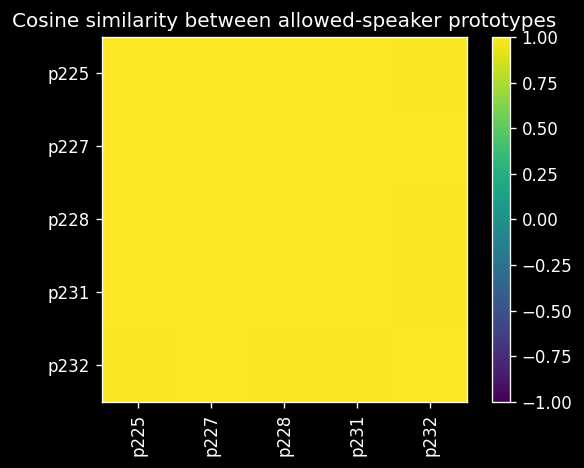

,p225,p227,p228,p231,p232
p225,1.000000,0.997655,0.999623,0.997498,0.991844
p227,0.997655,1.000000,0.996985,0.998552,0.996322
p228,0.999623,0.996985,1.000000,0.996436,0.991920
p231,0.997498,0.998552,0.996436,1.000000,0.991388
p232,0.991844,0.996322,0.991920,0.991388,1.000000


In [23]:
prototype_names = sorted(speaker_index["prototypes"].keys())

if len(prototype_names) > 0:
    P = np.stack([speaker_index["prototypes"][name] for name in prototype_names], axis=0)
    sim_matrix = P @ P.T

    fig, ax = plt.subplots(figsize=(max(5, 0.5 * len(prototype_names)), max(4, 0.5 * len(prototype_names))))
    im = ax.imshow(sim_matrix, vmin=-1, vmax=1)
    ax.set_xticks(range(len(prototype_names)))
    ax.set_yticks(range(len(prototype_names)))
    ax.set_xticklabels(prototype_names, rotation=90)
    ax.set_yticklabels(prototype_names)
    ax.set_title("Cosine similarity between allowed-speaker prototypes")
    fig.colorbar(im, ax=ax, fraction=0.046)
    save_plot("allowed_speaker_prototype_similarity_matrix.png")
    plt.show()

    proto_sim_df = pd.DataFrame(sim_matrix, index=prototype_names, columns=prototype_names)
    display(proto_sim_df)


# 5. Background-noise robustness study

Background noise is one of the main practical difficulties in a voice-based access-control system.  
This section evaluates the final model under controlled synthetic white noise at several SNR levels. Clean audio is shown as `30 dB` only for plotting convenience.


## 5.1 Evaluate clean and noisy recordings on all splits

This cell creates synthetic noise files and then evaluates train, validation, and test recordings under clean and noisy conditions.
Both binary and prototype modes are evaluated so that their robustness can be compared.


In [24]:
noise_files = vap.create_synthetic_noise_files(
    NOISE_DIR,
    sample_rate=16000,
    duration_seconds=30.0,
    n_files_per_kind=5,
    kinds=("white", "pink"),
    seed=SEED,
)
print(f"Generated {len(noise_files)} noise files in: {NOISE_DIR}")

noise_raw_summaries = []
noise_metric_summaries = []

for split in ["train", "valid", "test"]:
    noise_cfg = vap.NoiseStudyConfig(
        noise_dir=None,
        noise_kind="white",
        snr_levels=[20.0, 10.0, 5.0, 0.0],
        include_clean=True,
        split=split,
        n_recordings_per_split=None,
        seed=SEED,
    )

    raw_df, summary_df = vap.evaluate_experiment_under_noise(
        final_config,
        noise_cfg,
        modes=("binary", "prototype"),
    )

    noise_raw_summaries.append(raw_df)
    noise_metric_summaries.append(summary_df)

noise_raw_df = pd.concat(noise_raw_summaries, ignore_index=True)
noise_summary_df = pd.concat(noise_metric_summaries, ignore_index=True)

noise_summary_df


Generated 10 noise files in: voice_access_files\synthetic_noise


Noise evaluation:   0%|          | 0/888 [00:00<?, ?it/s]

Noise evaluation:   0%|          | 0/201 [00:00<?, ?it/s]

Noise evaluation:   0%|          | 0/220 [00:00<?, ?it/s]

,experiment_name,mode,split,noise_kind,snr_db,n_total,n_allow,n_not_allow,false_accept,false_reject,far,frr,acc,balanced_error,gap_far_frr
0,final_operational_model,binary,train,clean,NaN,888,243,645,162,2,0.251163,0.008230,0.815315,0.129697,0.242932
1,final_operational_model,binary,train,white,0.0,888,243,645,13,151,0.020155,0.621399,0.815315,0.320777,0.601244
2,final_operational_model,binary,train,white,5.0,888,243,645,29,135,0.044961,0.555556,0.815315,0.300258,0.510594
3,final_operational_model,binary,train,white,10.0,888,243,645,39,100,0.060465,0.411523,0.843468,0.235994,0.351058
4,final_operational_model,binary,train,white,20.0,888,243,645,83,31,0.128682,0.127572,0.871622,0.128127,0.001110
5,final_operational_model,prototype,train,clean,NaN,888,243,645,162,2,0.251163,0.008230,0.815315,0.129697,0.242932
6,final_operational_model,prototype,train,white,0.0,888,243,645,7,187,0.010853,0.769547,0.781532,0.390200,0.758695
7,final_operational_model,prototype,train,white,5.0,888,243,645,10,161,0.015504,0.662551,0.807432,0.339028,0.647048
8,final_operational_model,prototype,train,white,10.0,888,243,645,21,137,0.032558,0.563786,0.822072,0.298172,0.531228
9,final_operational_model,prototype,train,white,20.0,888,243,645,73,37,0.113178,0.152263,0.876126,0.132721,0.039085


## 5.2 Balanced error under noise

This plot shows how balanced error changes as SNR decreases.  
Separate curves are drawn for each split and each mode.


Saved: voice_access_files\results\plots\noise_robustness_balanced_error_by_split.png


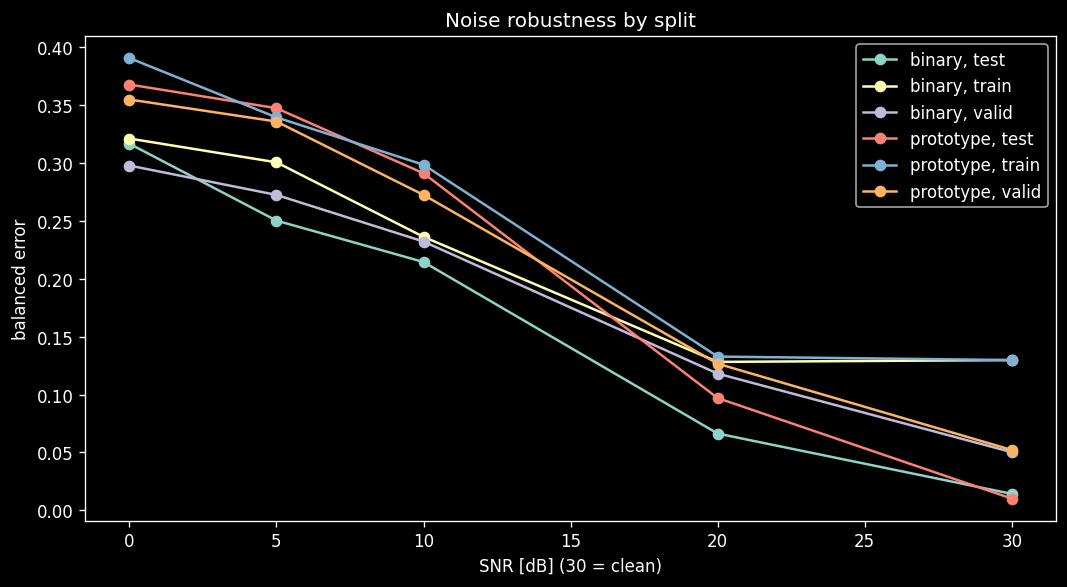

In [25]:
plot_df = noise_summary_df.copy()
plot_df["snr_plot"] = plot_df["snr_db"].fillna(30.0)

fig, ax = plt.subplots(figsize=(9, 5))

for (mode, split), g in plot_df.groupby(["mode", "split"]):
    g = g.sort_values("snr_plot")
    ax.plot(
        g["snr_plot"],
        g["balanced_error"],
        marker="o",
        label=f"{mode}, {split}",
    )

ax.set_xlabel("SNR [dB] (30 = clean)")
ax.set_ylabel("balanced error")
ax.set_title("Noise robustness by split")
ax.legend()
save_plot("noise_robustness_balanced_error_by_split.png")
plt.show()


## 5.3 Prototype FAR and FRR under noise

This plot focuses on the operational prototype mode and shows FAR and FRR separately.


Saved: voice_access_files\results\plots\prototype_far_frr_under_noise_by_split.png


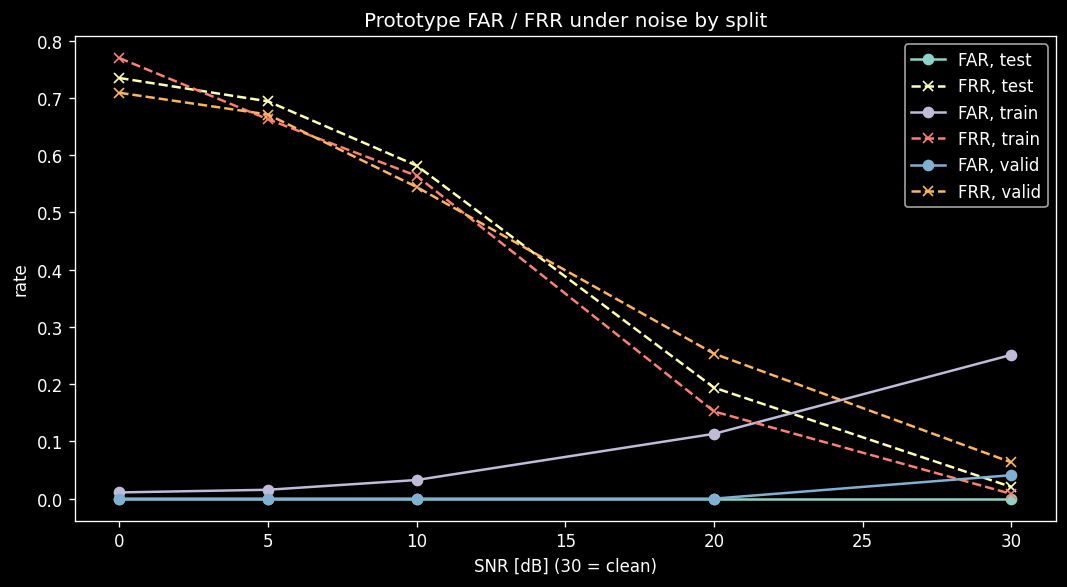

In [26]:
prototype_df = plot_df[plot_df["mode"] == "prototype"].copy()

fig, ax = plt.subplots(figsize=(9, 5))

for split, g in prototype_df.groupby("split"):
    g = g.sort_values("snr_plot")
    ax.plot(g["snr_plot"], g["far"], marker="o", label=f"FAR, {split}")
    ax.plot(g["snr_plot"], g["frr"], marker="x", linestyle="--", label=f"FRR, {split}")

ax.set_xlabel("SNR [dB] (30 = clean)")
ax.set_ylabel("rate")
ax.set_title("Prototype FAR / FRR under noise by split")
ax.legend()
save_plot("prototype_far_frr_under_noise_by_split.png")
plt.show()


## 5.4 Mean score by class under noise

These plots show how the average score for `allow` and `not_allow` recordings changes with noise level.  
If the class means move closer together under noise, the decision problem becomes harder.


Saved: voice_access_files\results\plots\noise_mean_score_by_class_binary_test.png


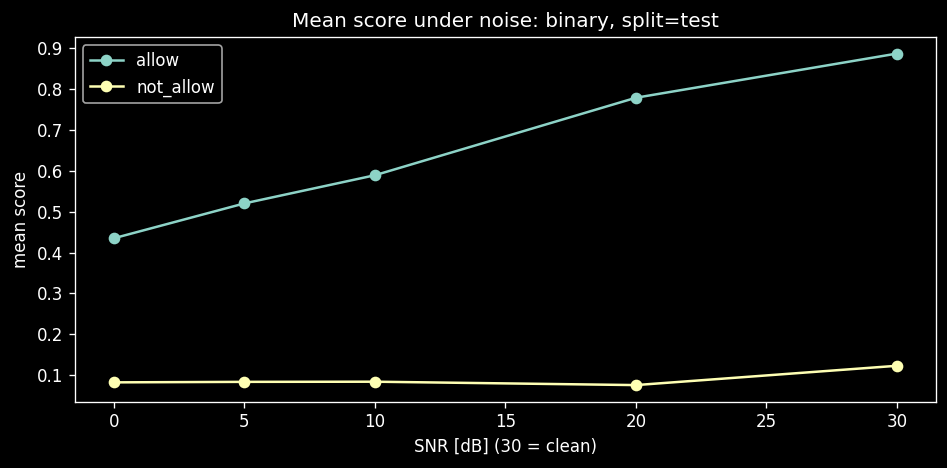

Saved: voice_access_files\results\plots\noise_mean_score_by_class_binary_train.png


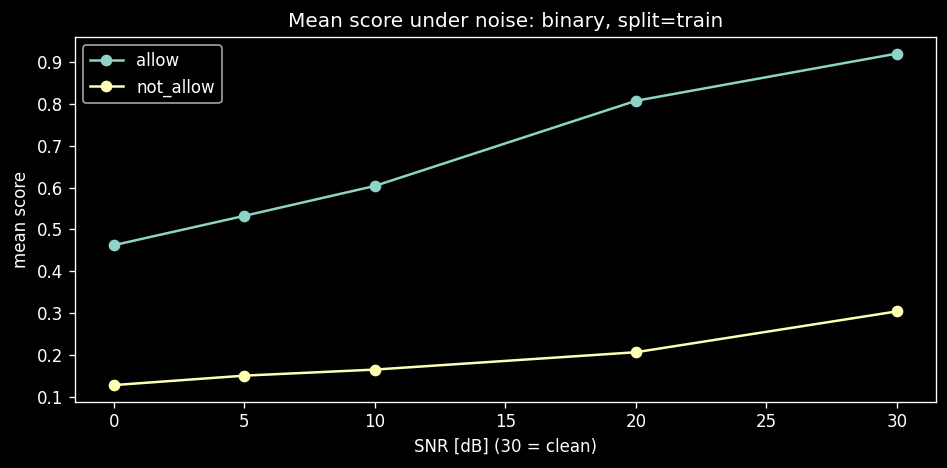

Saved: voice_access_files\results\plots\noise_mean_score_by_class_binary_valid.png


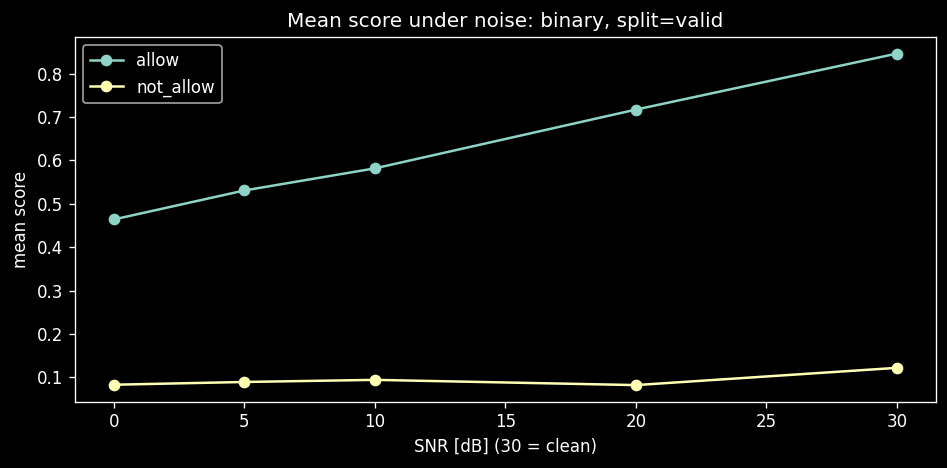

Saved: voice_access_files\results\plots\noise_mean_score_by_class_prototype_test.png


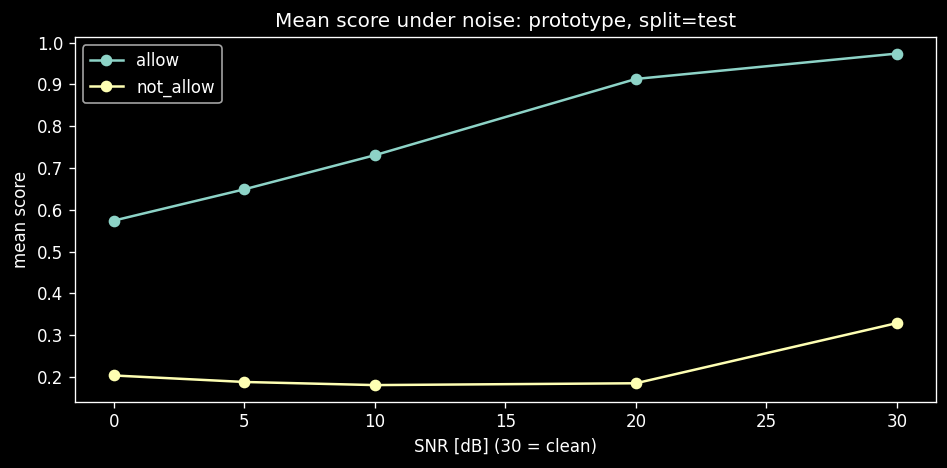

Saved: voice_access_files\results\plots\noise_mean_score_by_class_prototype_train.png


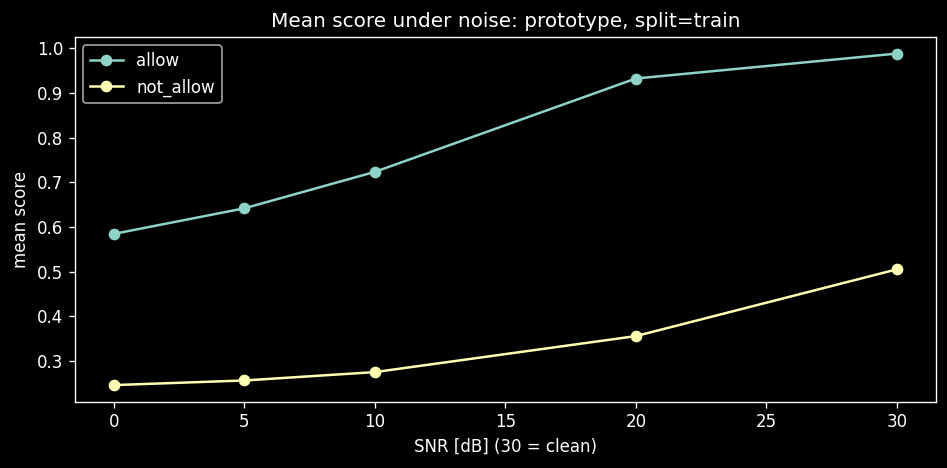

Saved: voice_access_files\results\plots\noise_mean_score_by_class_prototype_valid.png


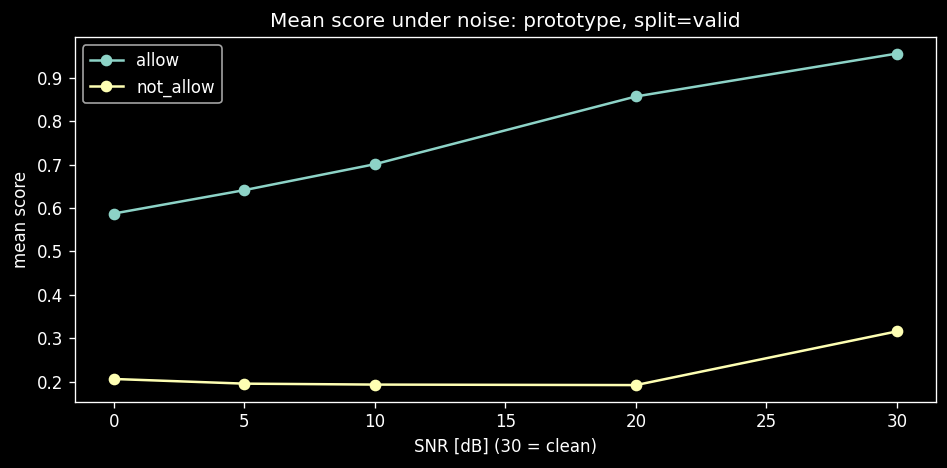

In [27]:
noise_plot_df = noise_raw_df.copy()
noise_plot_df["snr_plot"] = noise_plot_df["snr_db"].fillna(30.0)
noise_plot_df["class_name"] = np.where(noise_plot_df["y_true"] == 1, "allow", "not_allow")

mean_score_df = (
    noise_plot_df
    .groupby(["mode", "split", "snr_plot", "class_name"])["score"]
    .mean()
    .reset_index()
)

for (mode, split), g_mode in mean_score_df.groupby(["mode", "split"]):
    fig, ax = plt.subplots(figsize=(8, 4))

    for class_name, g in g_mode.groupby("class_name"):
        g = g.sort_values("snr_plot")
        ax.plot(g["snr_plot"], g["score"], marker="o", label=class_name)

    ax.set_title(f"Mean score under noise: {mode}, split={split}")
    ax.set_xlabel("SNR [dB] (30 = clean)")
    ax.set_ylabel("mean score")
    ax.legend()
    save_plot(f"noise_mean_score_by_class_{mode}_{split}.png")
    plt.show()


## 5.5 Speakers most affected by noise

This table-based analysis identifies speakers and SNR levels responsible for the largest number of noisy-condition mistakes.


In [28]:
noise_errors = noise_plot_df[noise_plot_df["y_true"] != noise_plot_df["predicted_label"]].copy()

error_by_speaker = (
    noise_errors
    .groupby(["mode", "speaker", "class_name"])
    .size()
    .reset_index(name="n_errors")
    .sort_values("n_errors", ascending=False)
)

display(error_by_speaker.head(30))

error_by_snr = (
    noise_errors
    .groupby(["mode", "snr_plot", "class_name"])
    .size()
    .reset_index(name="n_errors")
    .sort_values(["mode", "snr_plot", "class_name"])
)

display(error_by_snr)

error_by_speaker.to_csv(final_paths.results_dir / f"{final_config.experiment_name}_noise_errors_by_speaker.csv", index=False)
error_by_snr.to_csv(final_paths.results_dir / f"{final_config.experiment_name}_noise_errors_by_snr.csv", index=False)


,mode,speaker,class_name,n_errors
16,prototype,p227,allow,254
14,prototype,p225,allow,243
2,binary,p227,allow,226
17,prototype,p228,allow,175
0,binary,p225,allow,168
21,prototype,p232,allow,150
3,binary,p228,allow,144
1,binary,p226,not_allow,138
7,binary,p232,allow,131
15,prototype,p226,not_allow,114


,mode,snr_plot,class_name,n_errors
0,binary,0.0,allow,260
1,binary,0.0,not_allow,13
2,binary,5.0,allow,227
3,binary,5.0,not_allow,29
4,binary,10.0,allow,178
5,binary,10.0,not_allow,40
6,binary,20.0,allow,62
7,binary,20.0,not_allow,84
8,binary,30.0,allow,10
9,binary,30.0,not_allow,166


# 6. Adding a new allowed speaker

The final system supports incremental enrollment in prototype mode.  
A new person's recordings are converted into embeddings, averaged into a new prototype, and added to the existing speaker index. This avoids retraining the CNN from scratch for every new allowed person.


In [29]:
# Example usage:
# new_person_dir = Path('VOiCES\source-16k\new_person')
# final_checkpoint = vap.get_experiment_checkpoint_path(final_config)
# enrollment_result = vap.enroll_new_allowed_speaker_operational(
#     base_config=final_config,
#     checkpoint_path=final_checkpoint,
#     new_speaker_dir=new_person_dir,
#     speaker_name='new_person',
#     overwrite_source=False,
# )
# enrollment_result
